## Imports and paths

In [16]:
# stdlib
import sys
import yaml
from pathlib import Path

# third-party
import atlite
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import pypsa
import xarray as xr
from atlite.resource import get_windturbineconfig

# directory set up on cluster

# root = Path.cwd()
# pypsa_eur_root = root  
# home_root = root.parent        

# pypsa_dmg_root = home_root / "pypsa-damage"
# pypsa_eur_scripts = pypsa_eur_root / "scripts"

# sys.path.insert(0, str(pypsa_eur_scripts / "_testing"))

# directory set up on local machine
root = Path.cwd()
pypsa_eur_root = root.parent.parent  
home_root = pypsa_eur_root.parent        

pypsa_dmg_root = home_root / "pypsa-damage"
pypsa_eur_scripts = pypsa_eur_root / "scripts"

sys.path.insert(0, str(pypsa_eur_root))
sys.path.insert(0, str(pypsa_eur_scripts))
sys.path.insert(0, str(pypsa_eur_scripts / "_testing"))

In [17]:
sys.path

['/home/lois/pypsa-eur/pypsa-eur/scripts/_testing',
 '/home/lois/pypsa-eur/pypsa-eur/scripts',
 '/home/lois/pypsa-eur/pypsa-eur',
 '/home/lois/pypsa-eur/pypsa-eur/scripts/_testing',
 '/home/lois/pypsa-eur/pypsa-eur/scripts',
 '/home/lois/pypsa-eur/pypsa-eur',
 '/home/lois/pypsa-eur/pypsa-eur/.pixi/envs/default/lib/python313.zip',
 '/home/lois/pypsa-eur/pypsa-eur/.pixi/envs/default/lib/python3.13',
 '/home/lois/pypsa-eur/pypsa-eur/.pixi/envs/default/lib/python3.13/lib-dynload',
 '',
 '/home/lois/pypsa-eur/pypsa-eur/.pixi/envs/default/lib/python3.13/site-packages']

In [18]:
from scripts.build_damage_profiles.build_wind_damage_profiles import compute_wind_damage, aggregate_to_buses
from plot_stats import compute_stats_diff, format_stats_df, iplot_stats_bar, plot_stats_bar
from plot_damage import (
    iplot_plant_profile,
    iplot_bus_profile,
    iplot_vulnerability_table,
    plot_plant_profile,
    plot_bus_profile,
    plot_vulnerability_table,
)

from plot_stats import eb_imap_network

from styles import _compute_day_ticks, _DAMAGE_COLORS

print("Imports OK")

Imports OK


In [19]:
# ===========================================================================
# CONFIGURATION — edit here
# ===========================================================================
CONFIG_NAME = "2021-GB"
YEAR        = 2021
CLUSTERS    = 5

SNAP_START  = "2021-06-01"
SNAP_END    = "2022-05-31 23:00"

CARRIERS = {
    "onwind":        ("availability_matrix_5_onwind.nc",        "Vestas_V112_3MW"),
    "offwind-ac":    ("availability_matrix_5_offwind-ac.nc",    "NREL_ReferenceTurbine_2020ATB_5.5MW"),
    "offwind-dc":    ("availability_matrix_5_offwind-dc.nc",    "NREL_ReferenceTurbine_2020ATB_5.5MW"),
}

_cutout_dir = pypsa_eur_root / "data/cutout/build/unknown"
CUTOUT_PATHS = [
    _cutout_dir / f"europe-{YEAR}-era5_fg10_lmlt.nc",
    _cutout_dir / f"europe-{YEAR + 1}-era5_fg10_lmlt.nc",
]

_results = pypsa_eur_root / "results" / CONFIG_NAME

_COST_VARIANTS = ["LGLP", "LGHP", "HGLP", "HGHP"]

SCENARIO_VARIANTS = {
    **{f"cap_{v}": f"weather_year_{YEAR}_win_cap_{v}" for v in _COST_VARIANTS},
    **{f"dis_{v}": f"weather_year_{YEAR}_win_dis_{v}" for v in _COST_VARIANTS},
}

NETWORK_PATHS = {
    **{
        f"base_{v}": _results / f"weather_year_{YEAR}_win_dis_{v}" / "networks" / "base_s_5_elec_.nc"
        for v in _COST_VARIANTS
    },
    **{
        f"cap_{v}": _results / f"weather_year_{YEAR}_win_cap_{v}" / "networks" / "base_s_5_elec_.nc"
        for v in _COST_VARIANTS
    },
    **{
        f"dis_{v}": _results / f"weather_year_{YEAR}_win_dis_{v}" / "networks" / "base_s_5_elec__damaged-dispatch.nc"
        for v in _COST_VARIANTS
    },
}



## Load gust data

In [5]:
snapshot_index = pd.date_range(start=f"{YEAR + 1}-01-01", end=SNAP_END, freq="h", inclusive="both")
CUTOUT_DIR = CUTOUT_PATHS[0].parent

GUST_CACHE = CUTOUT_DIR / f"wnd_gust10m_{YEAR + 1}-01_{YEAR + 1}-05.nc"

cutout_y2 = atlite.Cutout(CUTOUT_PATHS[1])

if GUST_CACHE.exists():
    V_p = xr.open_dataarray(GUST_CACHE)
    print(f"Loaded from cache: {GUST_CACHE}")
else:
    V_p = cutout_y2.data["wnd_gust10m"].sel(time=slice(f"{YEAR + 1}-01-01", SNAP_END))
    V_p.to_netcdf(GUST_CACHE)
    print(f"Saved to cache: {GUST_CACHE}")


Loaded from cache: /home/lois/pypsa-eur/pypsa-eur/data/cutout/build/unknown/wnd_gust10m_2022-01_2022-05.nc


## bus to cell mapping

In [6]:
cutout_2022 = atlite.Cutout(_cutout_dir / "europe-2022-era5_fg10_lmlt.nc")

In [7]:
SCENARIO_DIR = pypsa_eur_root / "resources" / CONFIG_NAME / SCENARIO_VARIANTS["dis_LGLP"]
SCENARIO_DIR

PosixPath('/home/lois/pypsa-eur/pypsa-eur/resources/2021-GB/weather_year_2021_win_dis_LGLP')

/tmp/ipykernel_1688126/678388689.py:1: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



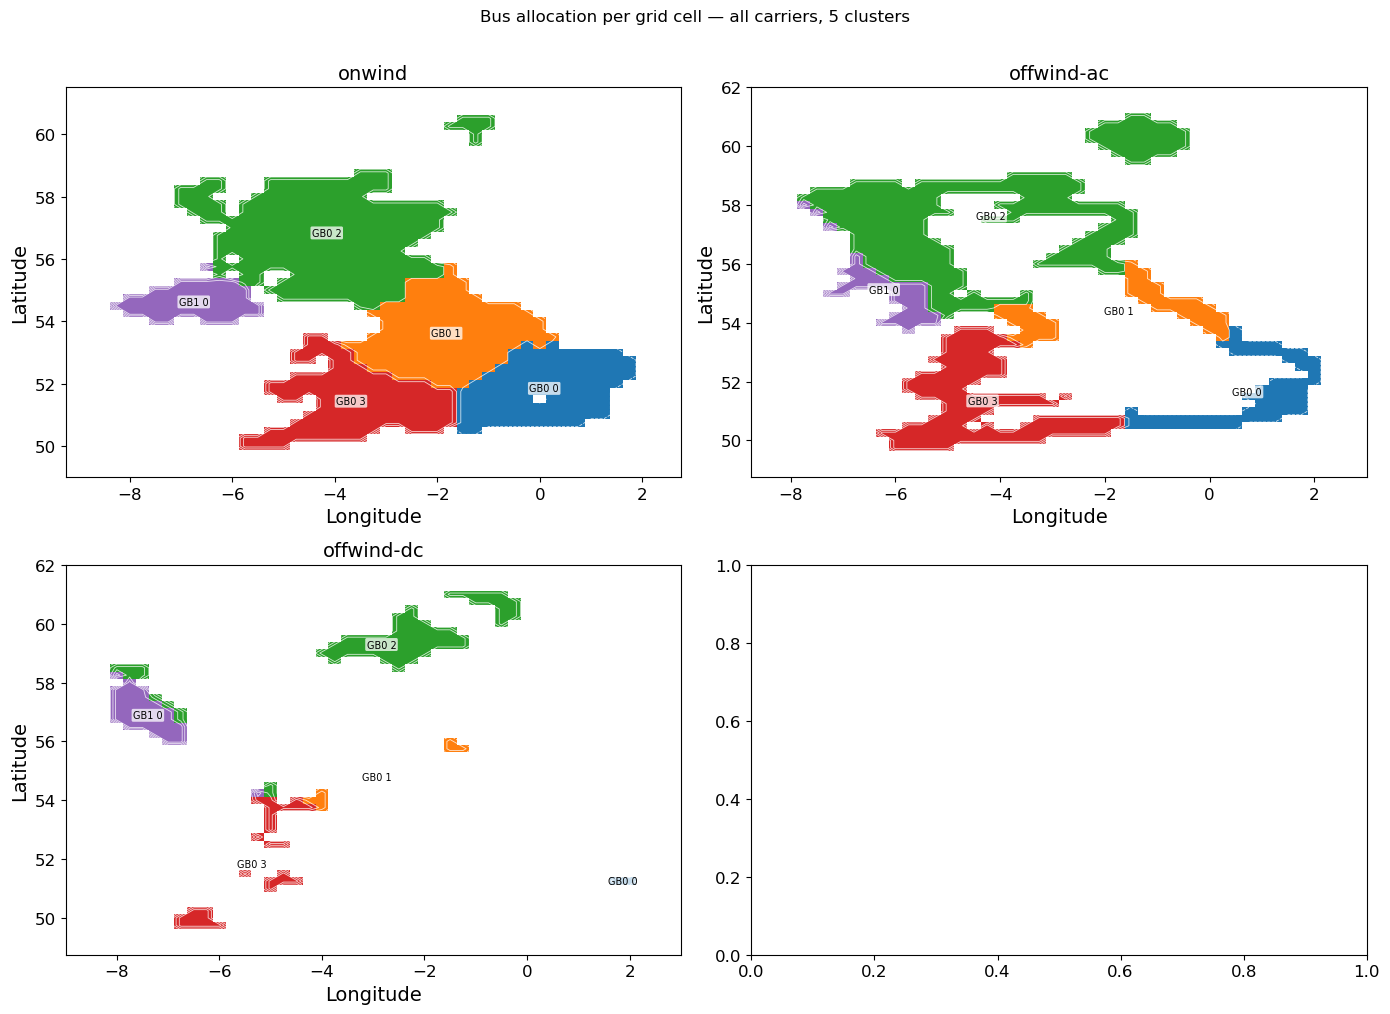

In [9]:
cmap = plt.cm.get_cmap("tab10")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (carrier, (avail_file, turbine)) in zip(axes.flat, CARRIERS.items()):
    avail = xr.open_dataarray(SCENARIO_DIR / avail_file)
    avail_total = avail.sum(dim="bus")
    has_avail = avail_total > 0

    # Colour each cell by dominant bus index
    dom_bus = avail.argmax(dim="bus").where(has_avail).astype(float)
    dom_bus.plot(ax=ax, cmap="tab10", vmin=0, vmax=9, add_colorbar=False)

    # Bus region borders via contour on the integer bus index array
    dom_int = avail.argmax(dim="bus").where(has_avail, other=-1)
    ax.contour(
        dom_int.x.values, dom_int.y.values, dom_int.values,
        levels=np.arange(-0.5, len(avail.bus) + 0.5, 1),
        colors="white", linewidths=0.6, alpha=0.8,
    )

    # Bus label at centroid of each region
    for i, bus in enumerate(avail.bus.values):
        mask = (avail.argmax(dim="bus") == i) & has_avail
        if mask.any():
            y_c = float(avail.y.where(mask).mean())
            x_c = float(avail.x.where(mask).mean())
            ax.text(x_c, y_c, bus, fontsize=7, ha="center", va="center",
                    bbox=dict(boxstyle="round,pad=0.15", facecolor="white", alpha=0.75, edgecolor="none"))

    # Zoom to active cells
    x_act = avail.x.where(has_avail.any(dim="y"), drop=True)
    y_act = avail.y.where(has_avail.any(dim="x"), drop=True)
    if len(x_act) and len(y_act):
        ax.set_xlim(float(x_act.min()) - 1, float(x_act.max()) + 1)
        ax.set_ylim(float(y_act.min()) - 1, float(y_act.max()) + 1)

    ax.set_title(carrier)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

plt.suptitle("Bus allocation per grid cell — all carriers, 5 clusters", y=1.01)
plt.tight_layout()
plt.show()


## Bus-level validation


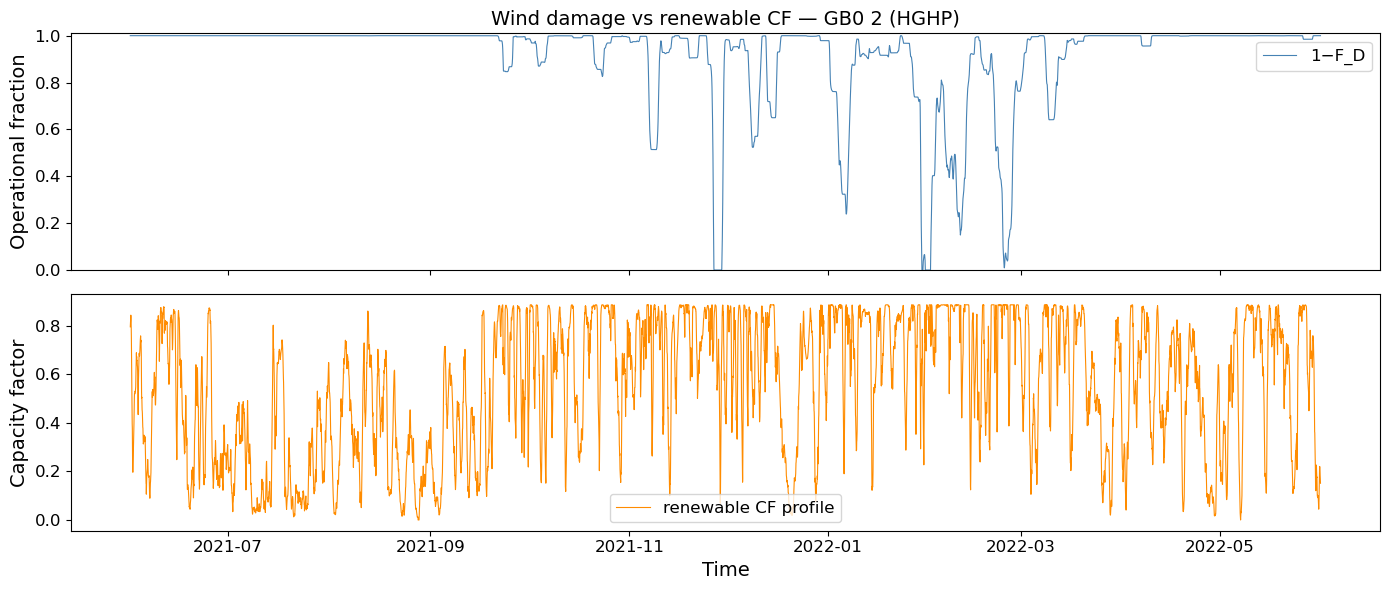

In [8]:
## 8. Plot — damage events vs renewable CF profile
CARRIER  = "offwind-ac"   # onwind | offwind-ac | offwind-dc
BUS      = "GB0 2"
VARIANT  = "HGHP"         # LGLP | LGHP | HGLP | HGHP

SCENARIO_DIR = pypsa_eur_root / "resources" / CONFIG_NAME / SCENARIO_VARIANTS[f"dis_{VARIANT}"]

_avail_file, TURBINE_NAME = CARRIERS[CARRIER]
AVAIL_PATH   = SCENARIO_DIR / _avail_file
PROFILE_PATH = SCENARIO_DIR / f"profile_5_{CARRIER}.nc"
DMG_PATH     = SCENARIO_DIR / "damage_profiles" / f"{CARRIER}_damage_5.nc"

op_existing = 1 - xr.open_dataset(DMG_PATH)["profile"]
cf_profile  = xr.open_dataset(PROFILE_PATH)["profile"]

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(op_existing.time.values, op_existing.sel(bus=BUS).values,
             color="steelblue", linewidth=0.8, label="1−F_D")
axes[0].set_ylabel("Operational fraction")
axes[0].set_ylim(0.0, 1.01)
axes[0].legend()
axes[0].set_title(f"Wind damage vs renewable CF — {BUS} ({VARIANT})")

axes[1].plot(cf_profile.time.values, cf_profile.sel(bus=BUS).squeeze().values,
             color="darkorange", linewidth=0.8, label="renewable CF profile")
axes[1].set_ylabel("Capacity factor")
axes[1].set_xlabel("Time")
axes[1].legend()

plt.tight_layout()
plt.show()


Wind damage vs renewable CF — GB0 2


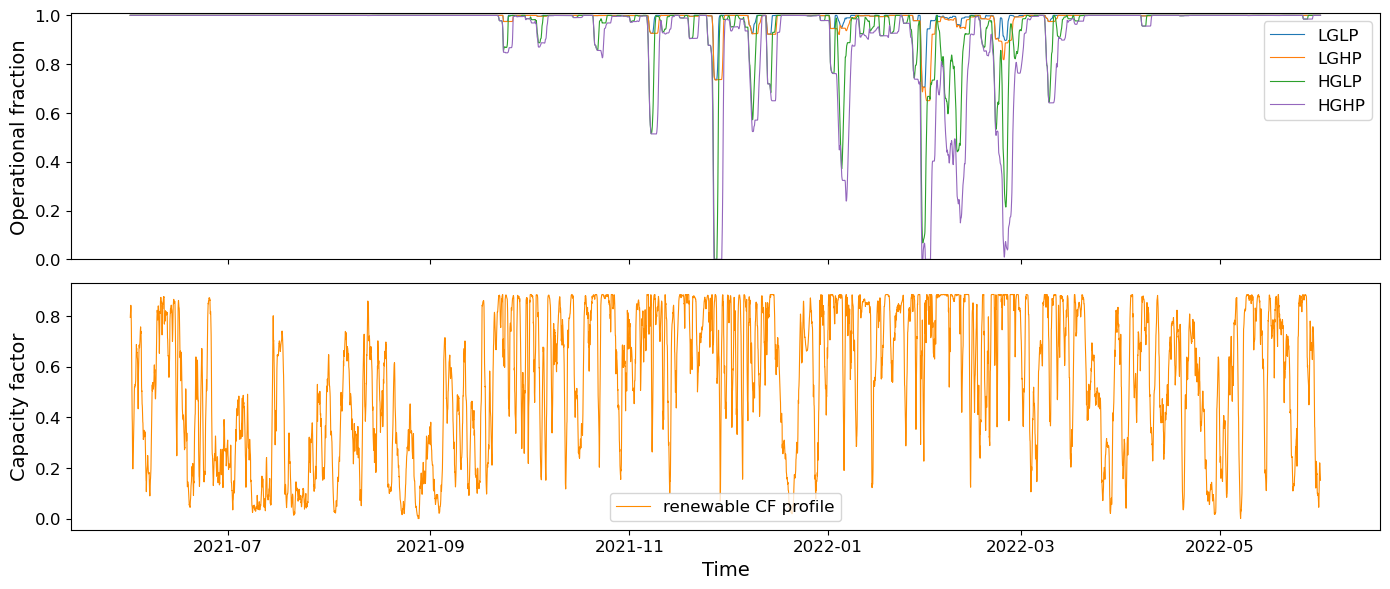

In [9]:
CARRIER  = "offwind-ac"
BUS      = "GB0 2"
VARIANTS = ["LGLP", "LGHP", "HGLP", "HGHP"]

_avail_file, TURBINE_NAME = CARRIERS[CARRIER]

# CF profile is the same across variants — load from first
_profile_dir = pypsa_eur_root / "resources" / CONFIG_NAME / SCENARIO_VARIANTS[f"dis_{VARIANTS[0]}"]
cf_profile = xr.open_dataset(_profile_dir / f"profile_5_{CARRIER}.nc")["profile"]

colors = plt.cm.tab10(np.linspace(0, 0.4, len(VARIANTS)))

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

for variant, color in zip(VARIANTS, colors):
    scenario_dir = pypsa_eur_root / "resources" / CONFIG_NAME / SCENARIO_VARIANTS[f"dis_{variant}"]
    dmg_path = scenario_dir / "damage_profiles" / f"{CARRIER}_damage_5.nc"
    op = 1 - xr.open_dataset(dmg_path)["profile"]
    axes[0].plot(op.time.values, op.sel(bus=BUS).values,
                 color=color, linewidth=0.8, label=variant)

axes[0].set_ylabel("Operational fraction")
axes[0].set_ylim(0.0, 1.01)
axes[0].legend()
print(f"Wind damage vs renewable CF — {BUS}")

axes[1].plot(cf_profile.time.values, cf_profile.sel(bus=BUS).squeeze().values,
             color="darkorange", linewidth=0.8, label="renewable CF profile")
axes[1].set_ylabel("Capacity factor")
axes[1].set_xlabel("Time")
axes[1].legend()

plt.tight_layout()
plt.show()


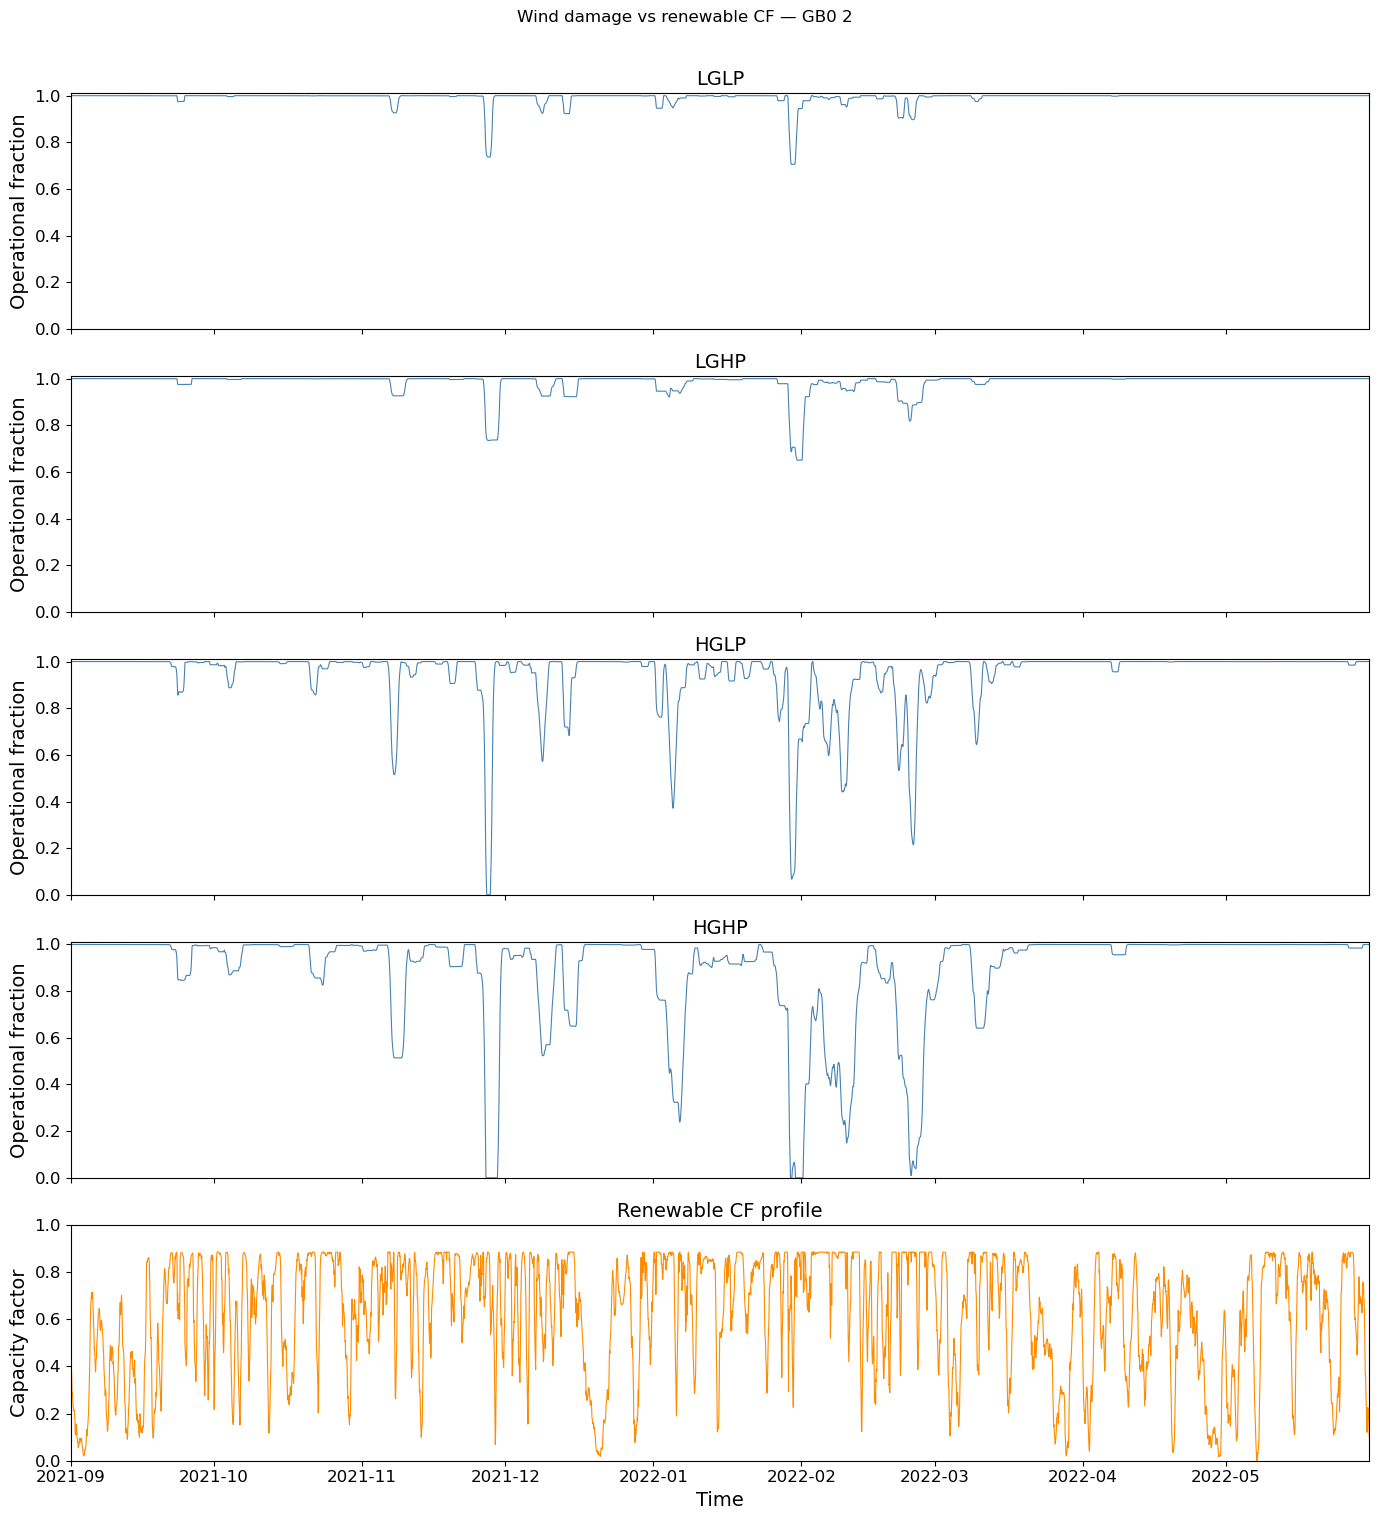

In [11]:
CARRIER  = "offwind-ac"
BUS      = "GB0 2"
VARIANTS = ["LGLP", "LGHP", "HGLP", "HGHP"]

_profile_dir = pypsa_eur_root / "resources" / CONFIG_NAME / SCENARIO_VARIANTS[f"dis_{VARIANTS[0]}"]
cf_profile = xr.open_dataset(_profile_dir / f"profile_5_{CARRIER}.nc")["profile"]

nrows = len(VARIANTS) + 1
fig, axes = plt.subplots(nrows, 1, figsize=(14, 3 * nrows), sharex=True)

for ax, variant in zip(axes, VARIANTS):
    scenario_dir = pypsa_eur_root / "resources" / CONFIG_NAME / SCENARIO_VARIANTS[f"dis_{variant}"]
    op = 1 - xr.open_dataset(scenario_dir / "damage_profiles" / f"{CARRIER}_damage_5.nc")["profile"]
    ax.plot(op.time.values, op.sel(bus=BUS).values,
            color="steelblue", linewidth=0.8, label="1−F_D")
    ax.set_ylabel("Operational fraction")
    ax.set_ylim(0, 1.01)
    ax.set_title(variant)
axes[-1].set_xlim(pd.Timestamp(f"{YEAR}-09-01"), pd.Timestamp(f"{YEAR+1}-05-31"))

axes[-1].plot(cf_profile.time.values, cf_profile.sel(bus=BUS).squeeze().values,
              color="darkorange", linewidth=0.8)
axes[-1].set_ylabel("Capacity factor")
axes[-1].set_ylim(0, 1)
axes[-1].set_title("Renewable CF profile")
axes[-1].set_xlabel("Time")

fig.suptitle(f"Wind damage vs renewable CF — {BUS}", y=1.01)
plt.tight_layout()
plt.show()


## change in operational fraction by variant per bus

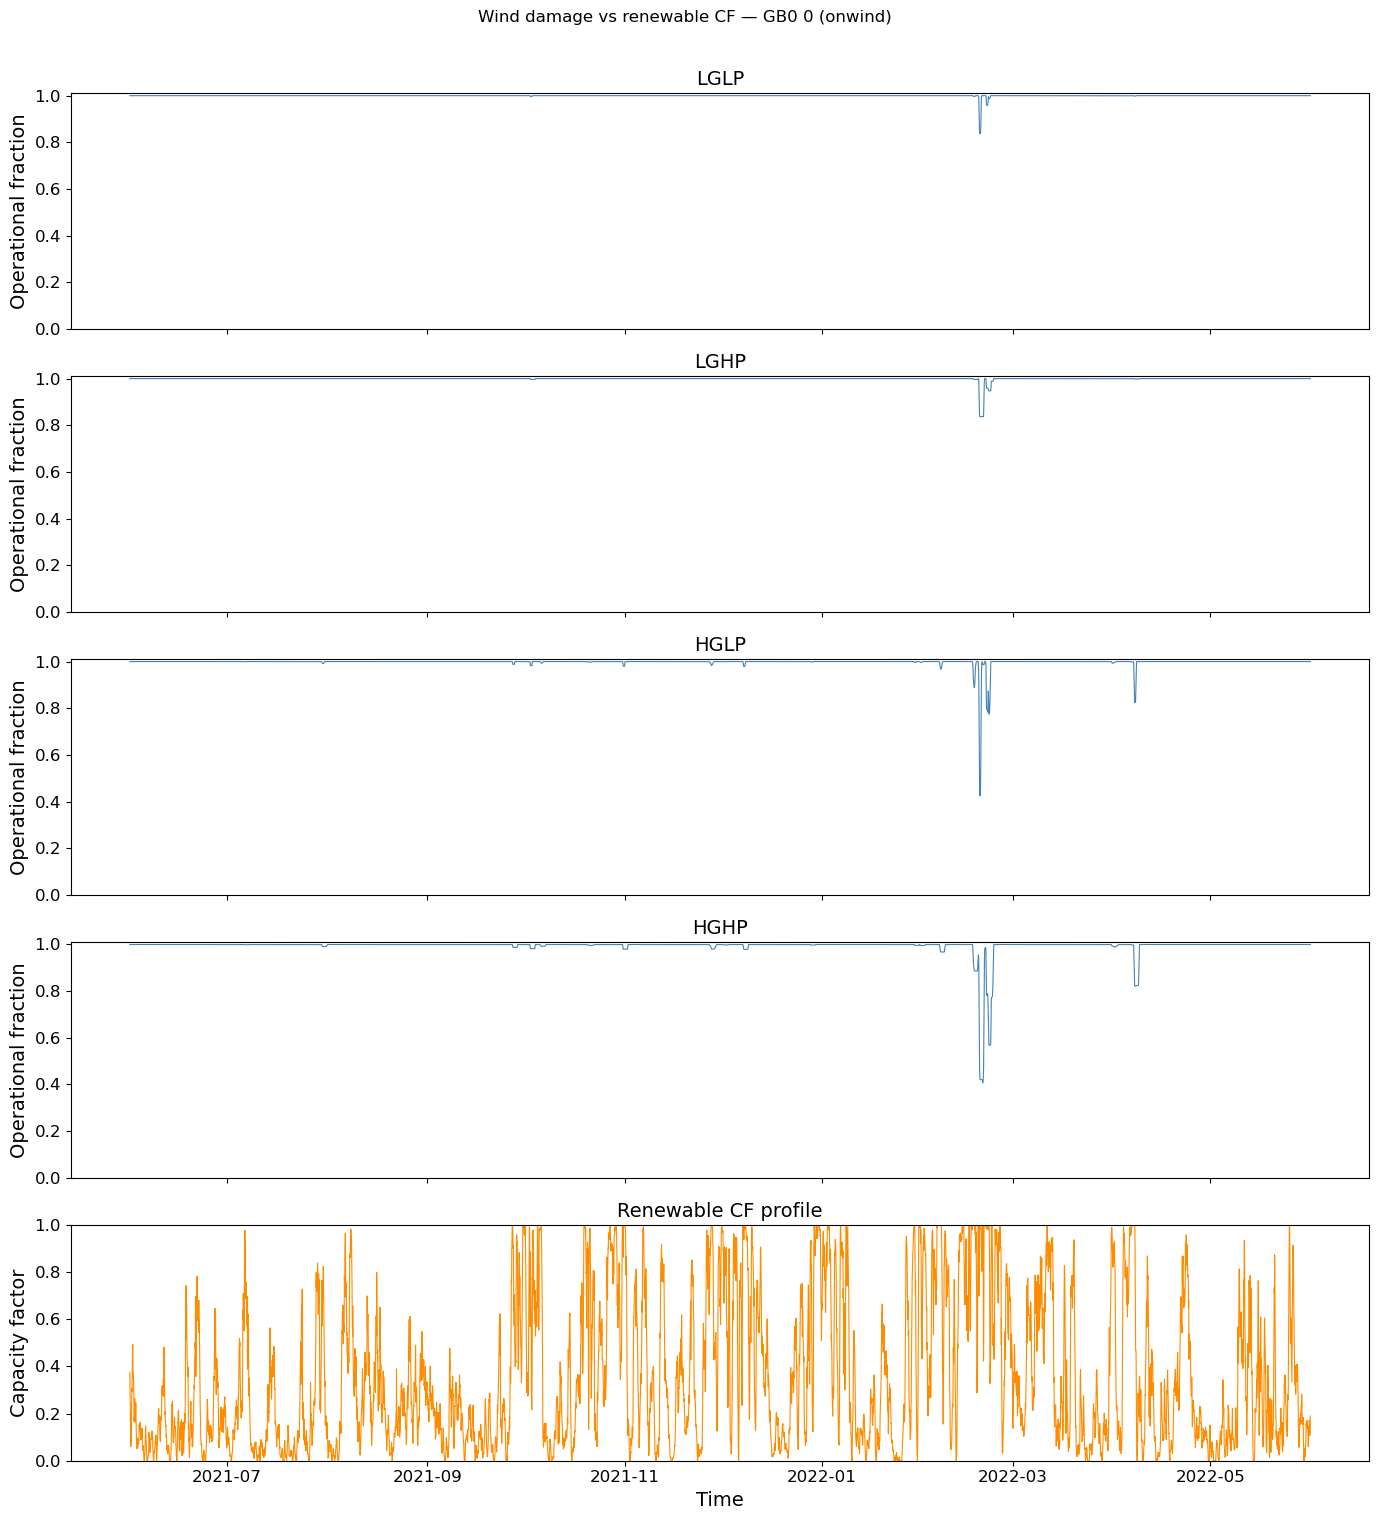

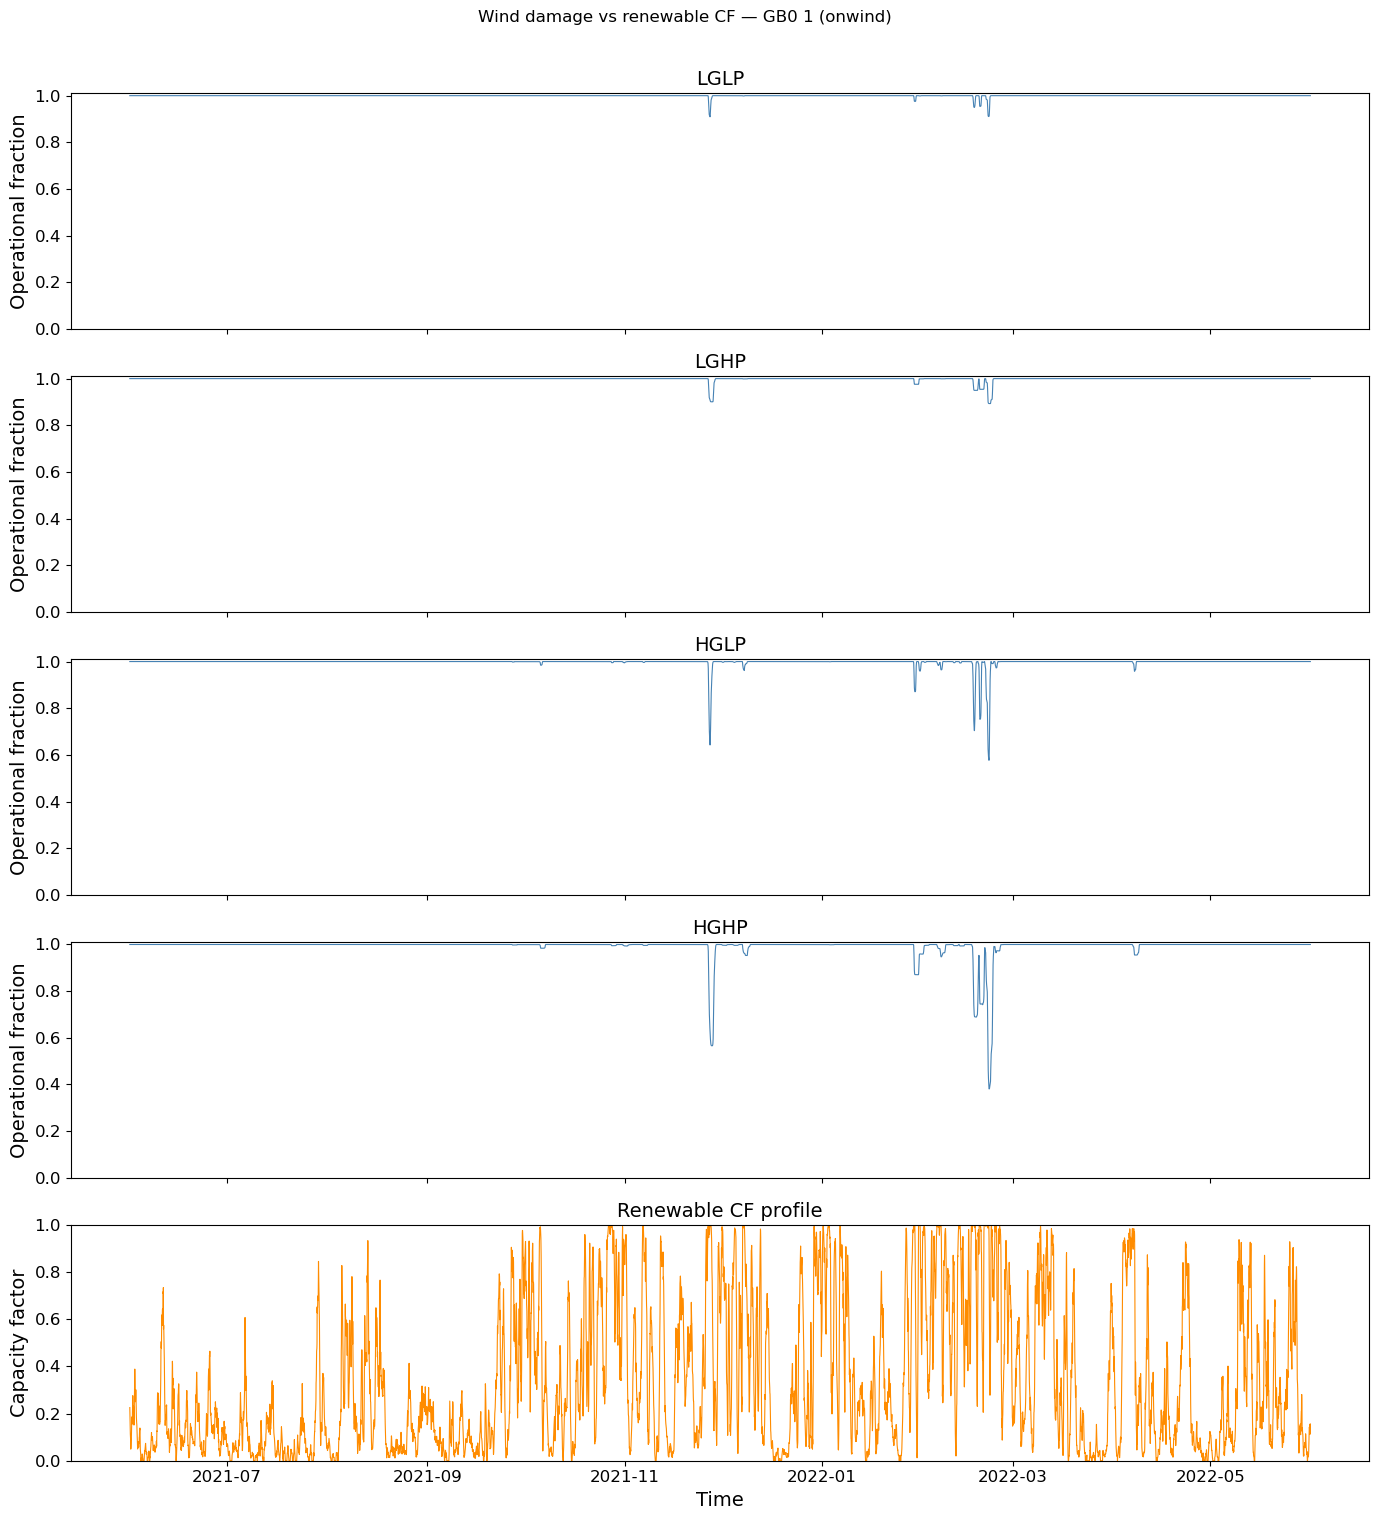

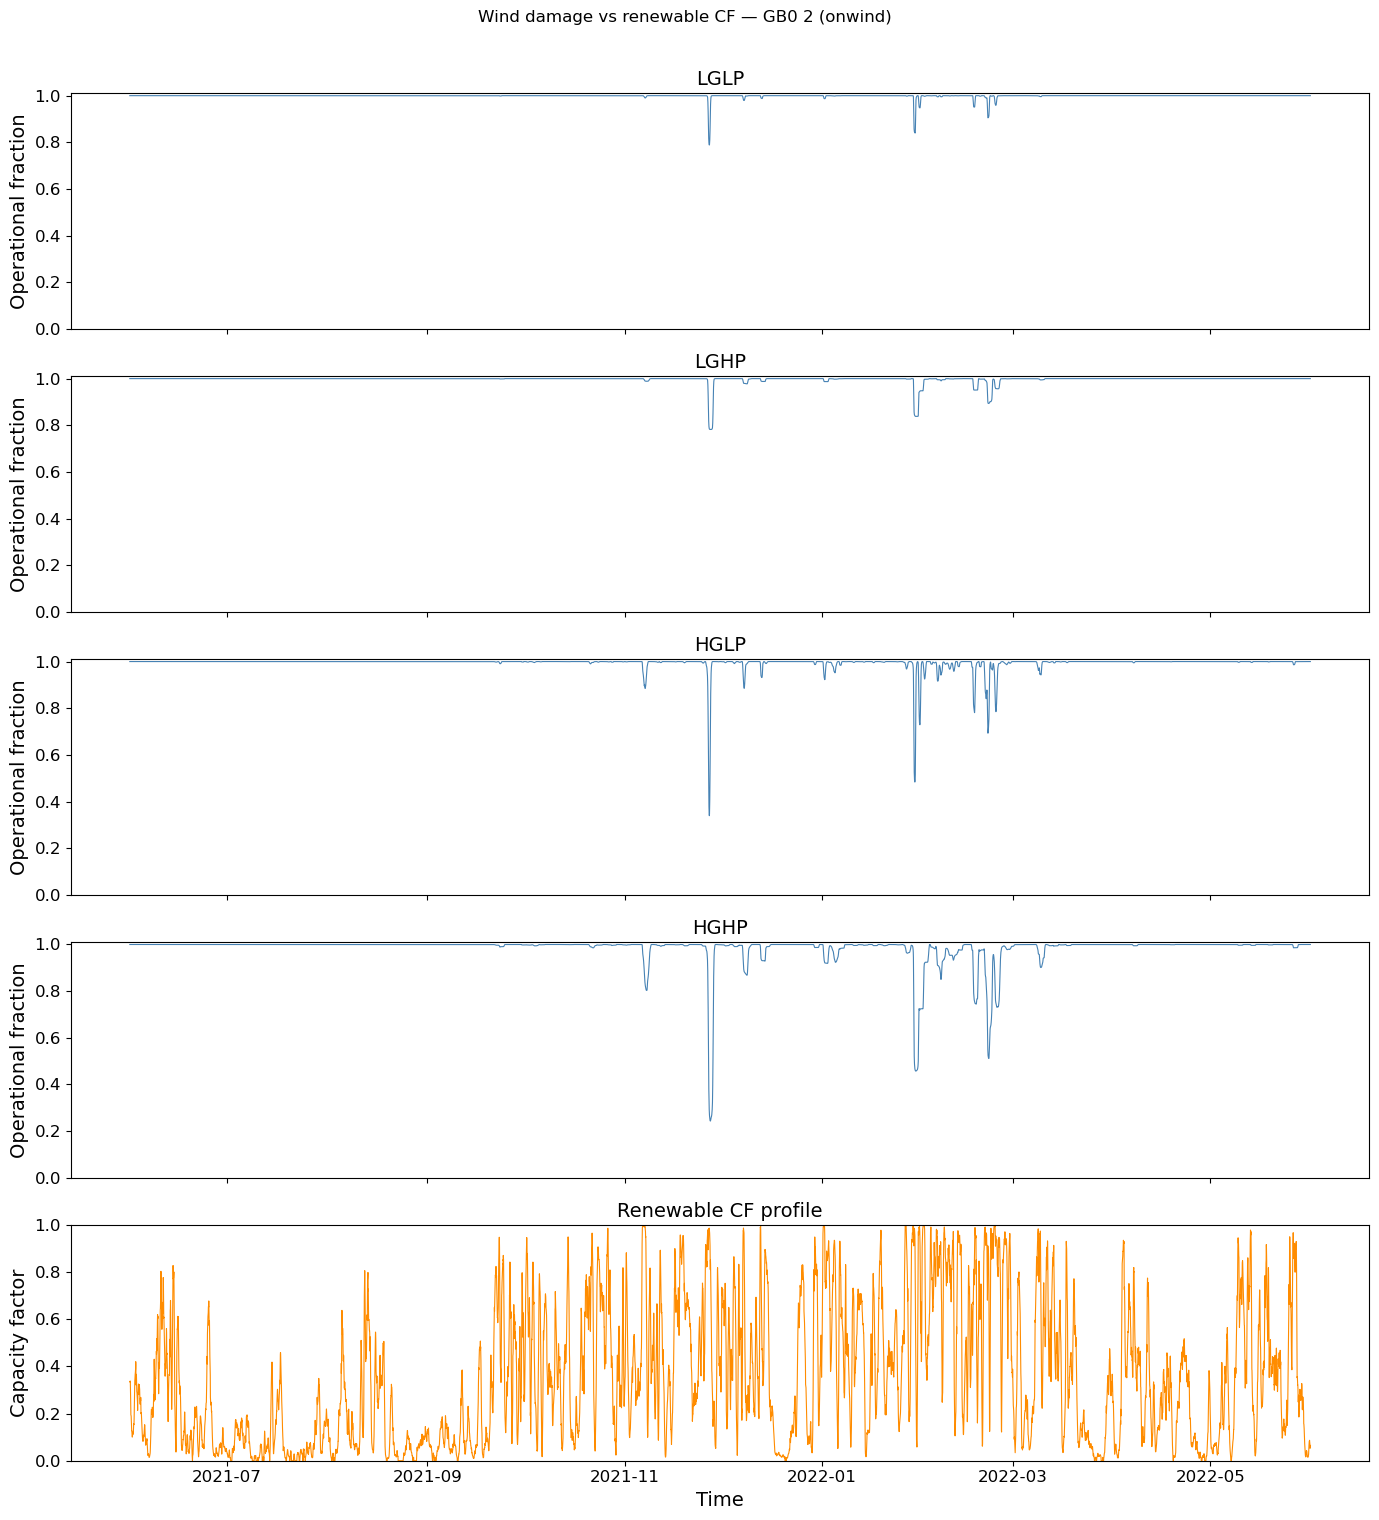

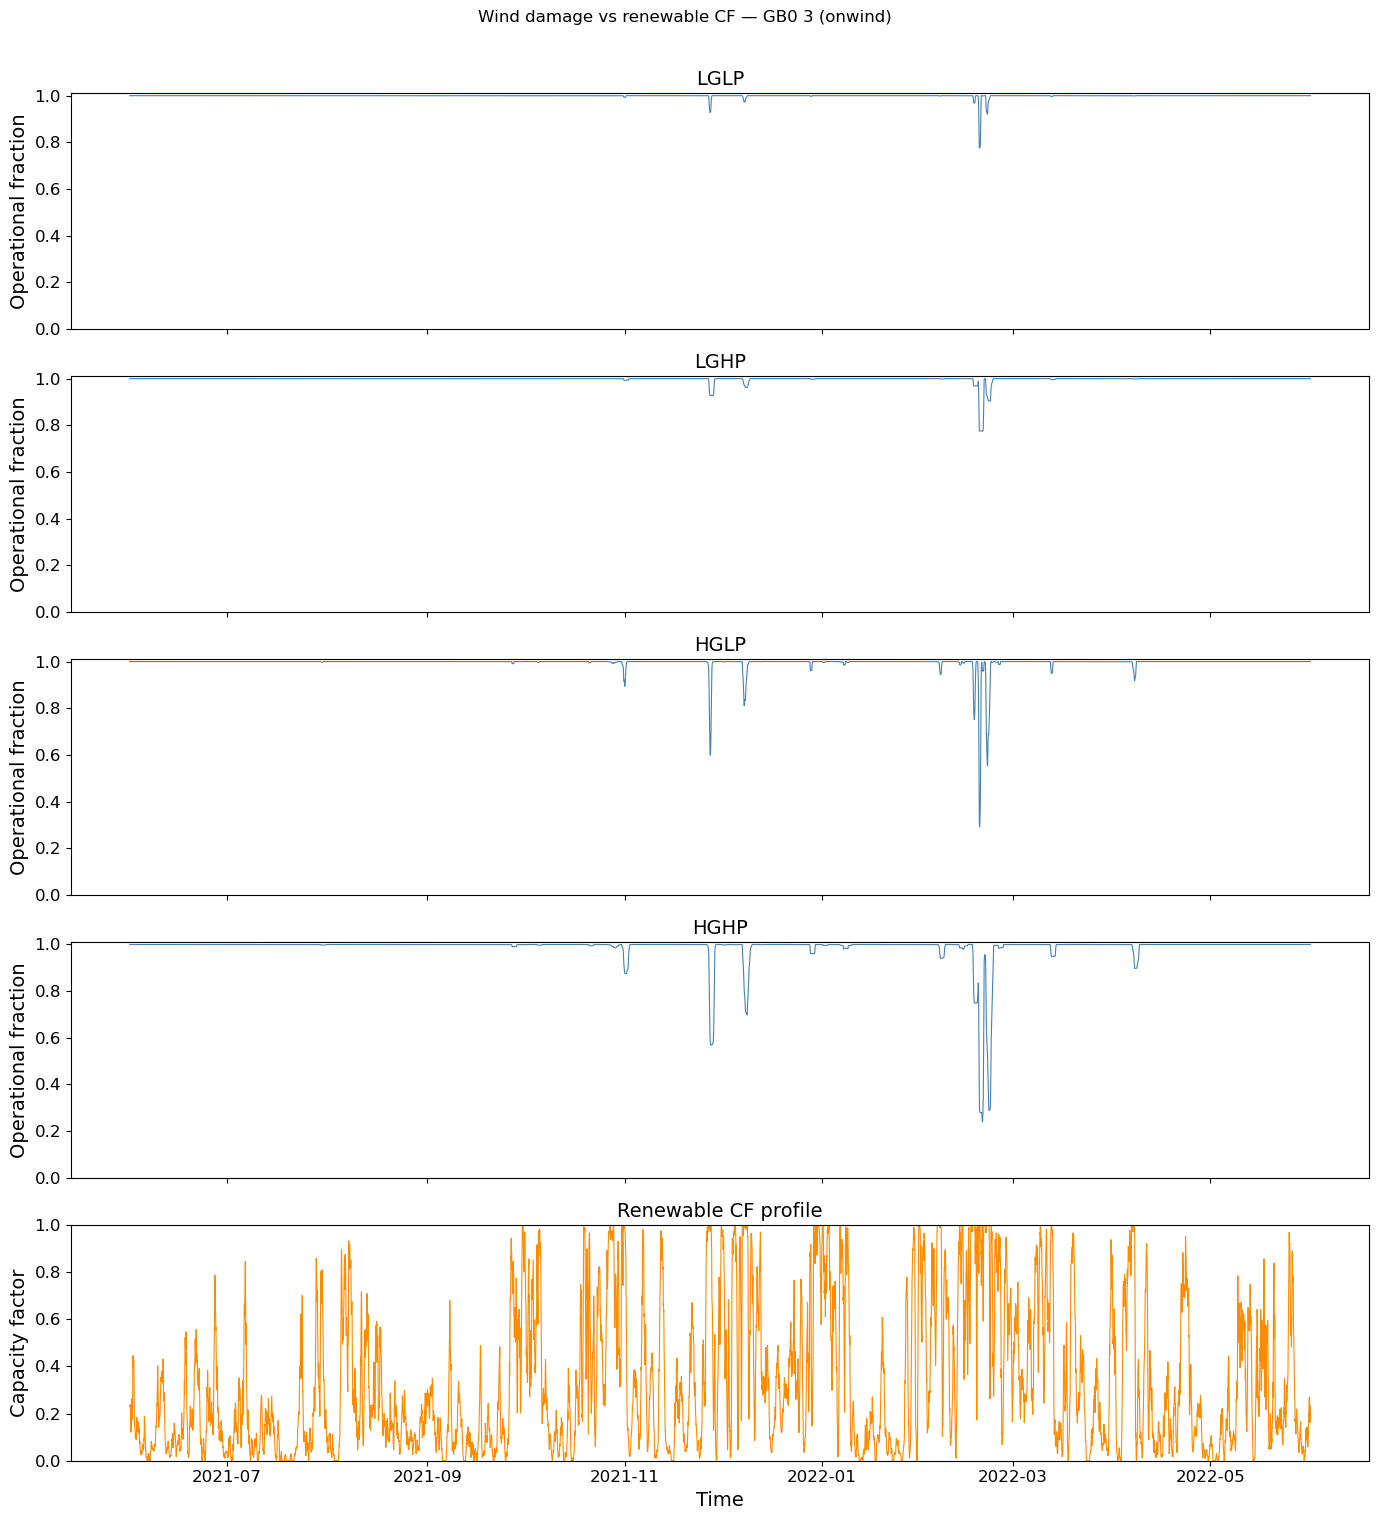

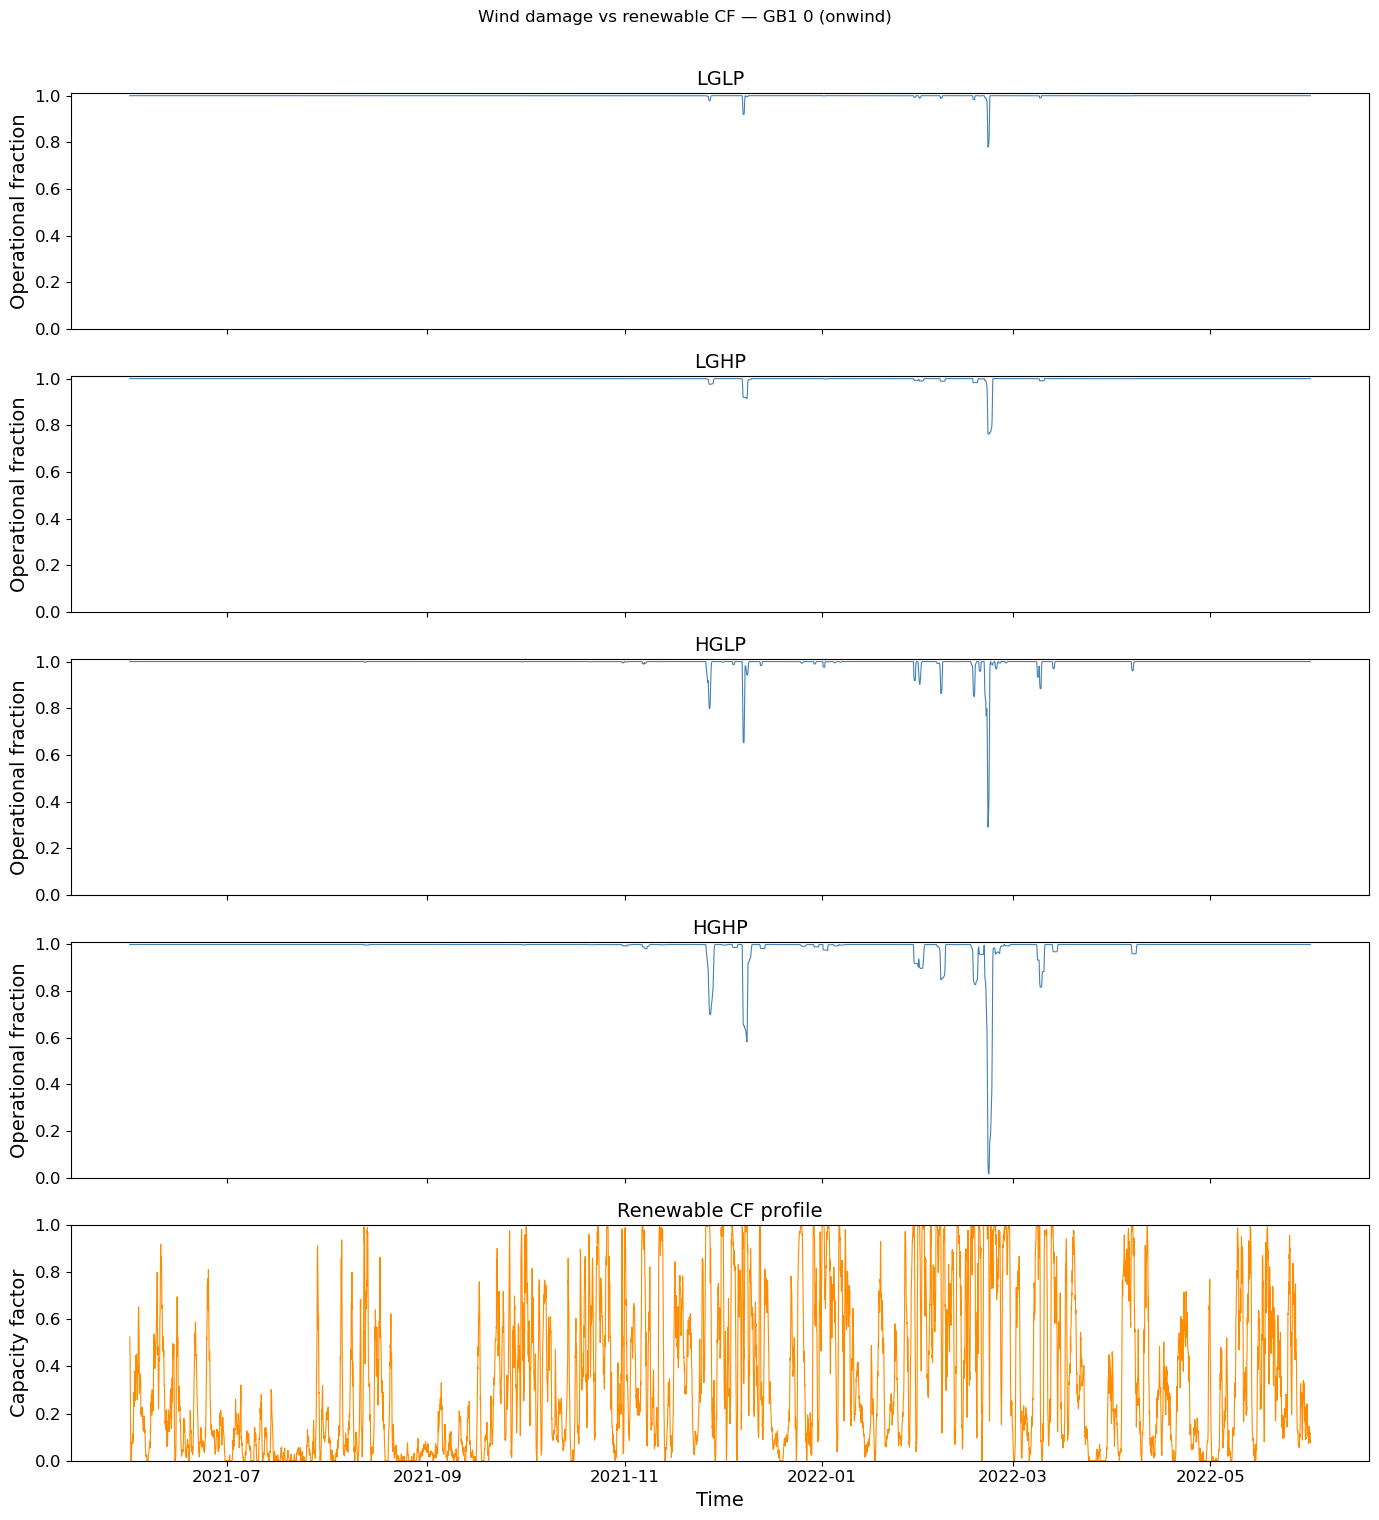

In [ ]:
CARRIER  = "offwind-dc"
VARIANTS = ["LGLP", "LGHP", "HGLP", "HGHP"]

_profile_dir = pypsa_eur_root / "resources" / CONFIG_NAME / SCENARIO_VARIANTS[f"dis_{VARIANTS[0]}"]
cf_profile = xr.open_dataset(_profile_dir / f"profile_5_{CARRIER}.nc")["profile"]
buses = cf_profile.bus.values.tolist()

nrows = len(VARIANTS) + 1

for bus in buses:
    fig, axes = plt.subplots(nrows, 1, figsize=(14, 3 * nrows), sharex=True)

    for ax, variant in zip(axes, VARIANTS):
        scenario_dir = pypsa_eur_root / "resources" / CONFIG_NAME / SCENARIO_VARIANTS[f"dis_{variant}"]
        op = 1 - xr.open_dataset(scenario_dir / "damage_profiles" / f"{CARRIER}_damage_5.nc")["profile"]
        ax.plot(op.time.values, op.sel(bus=bus).values,
                color="steelblue", linewidth=0.8, label="1−F_D")
        ax.set_ylabel("Operational fraction")
        ax.set_ylim(0, 1.01)
        ax.set_title(variant)

    axes[-1].plot(cf_profile.time.values, cf_profile.sel(bus=bus).squeeze().values,
                  color="darkorange", linewidth=0.8)
    axes[-1].set_ylabel("Capacity factor")
    axes[-1].set_ylim(0, 1)
    axes[-1].set_title("Renewable CF profile")
    axes[-1].set_xlabel("Time")

    fig.suptitle(f"Wind damage vs renewable CF — {bus} ({CARRIER})", y=1.01)
    plt.tight_layout()
    plt.show()


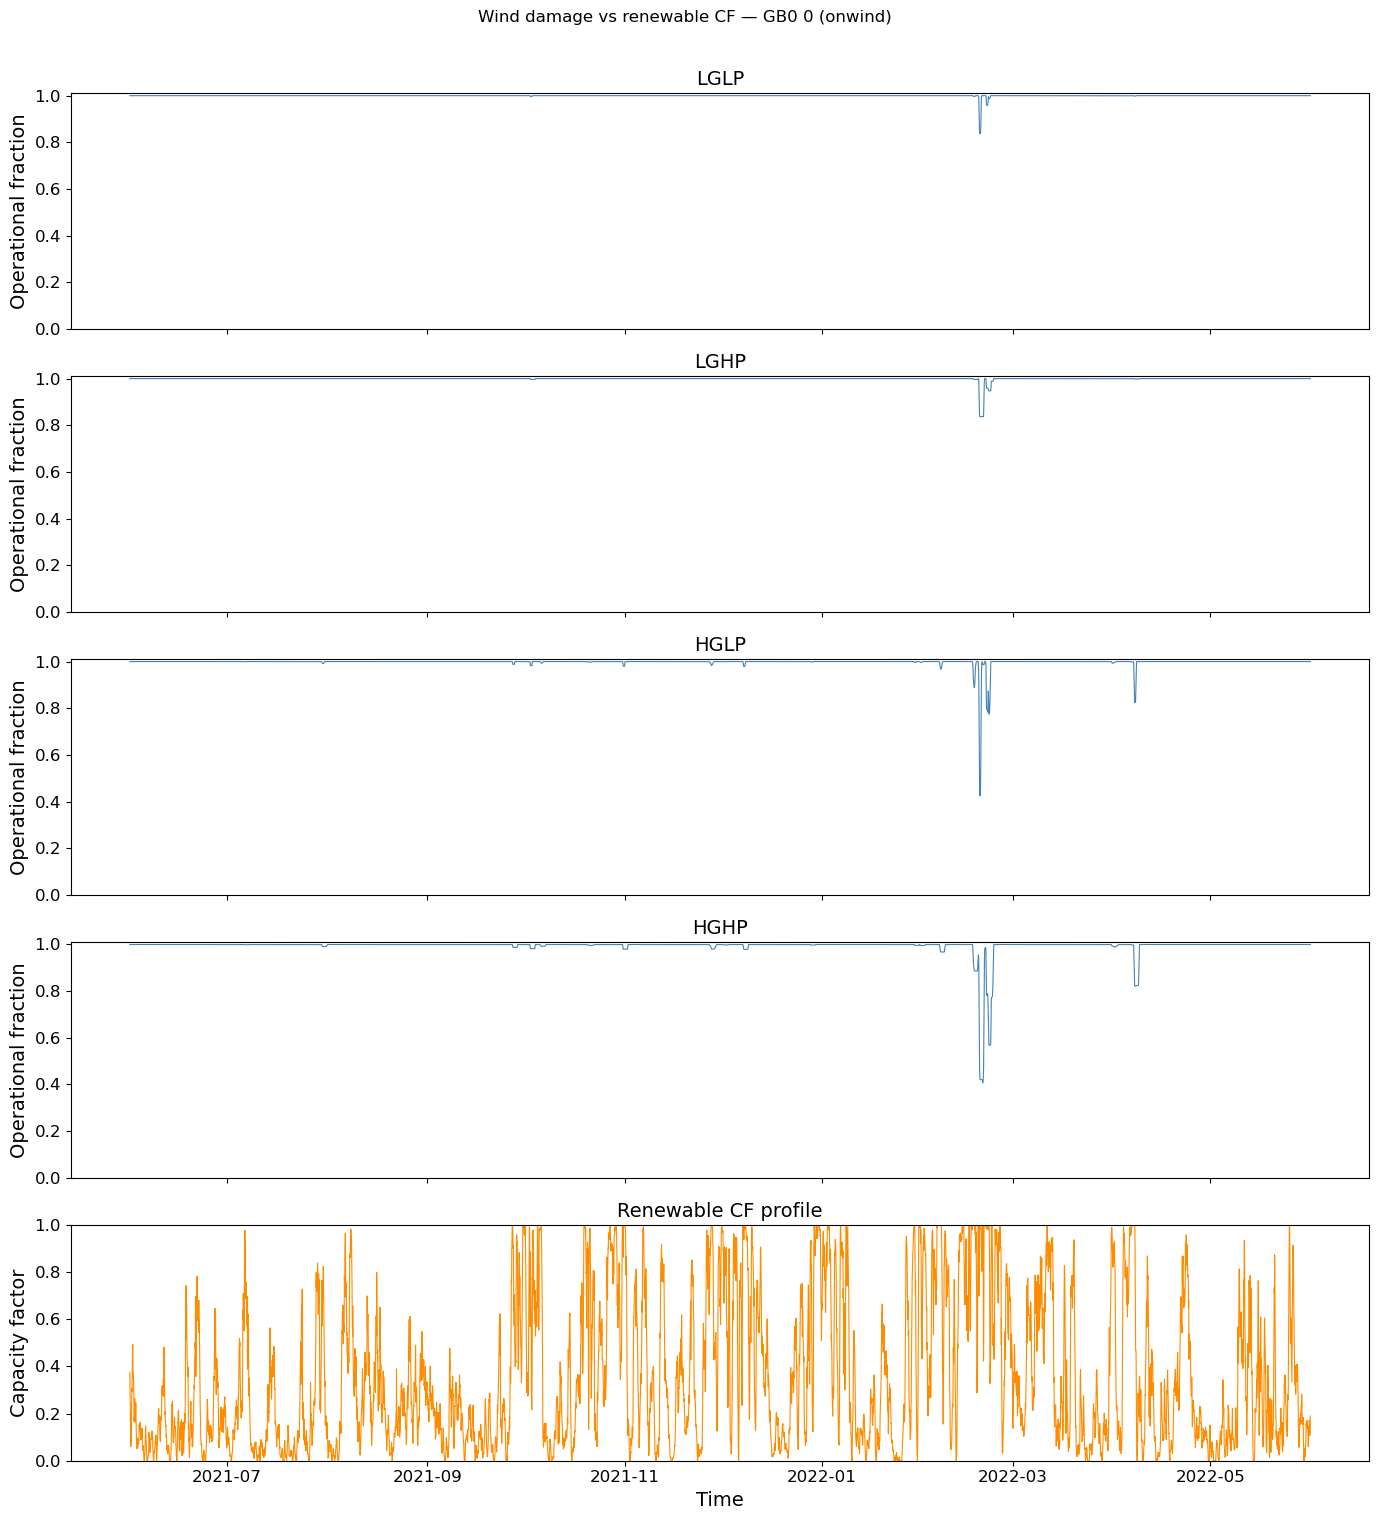

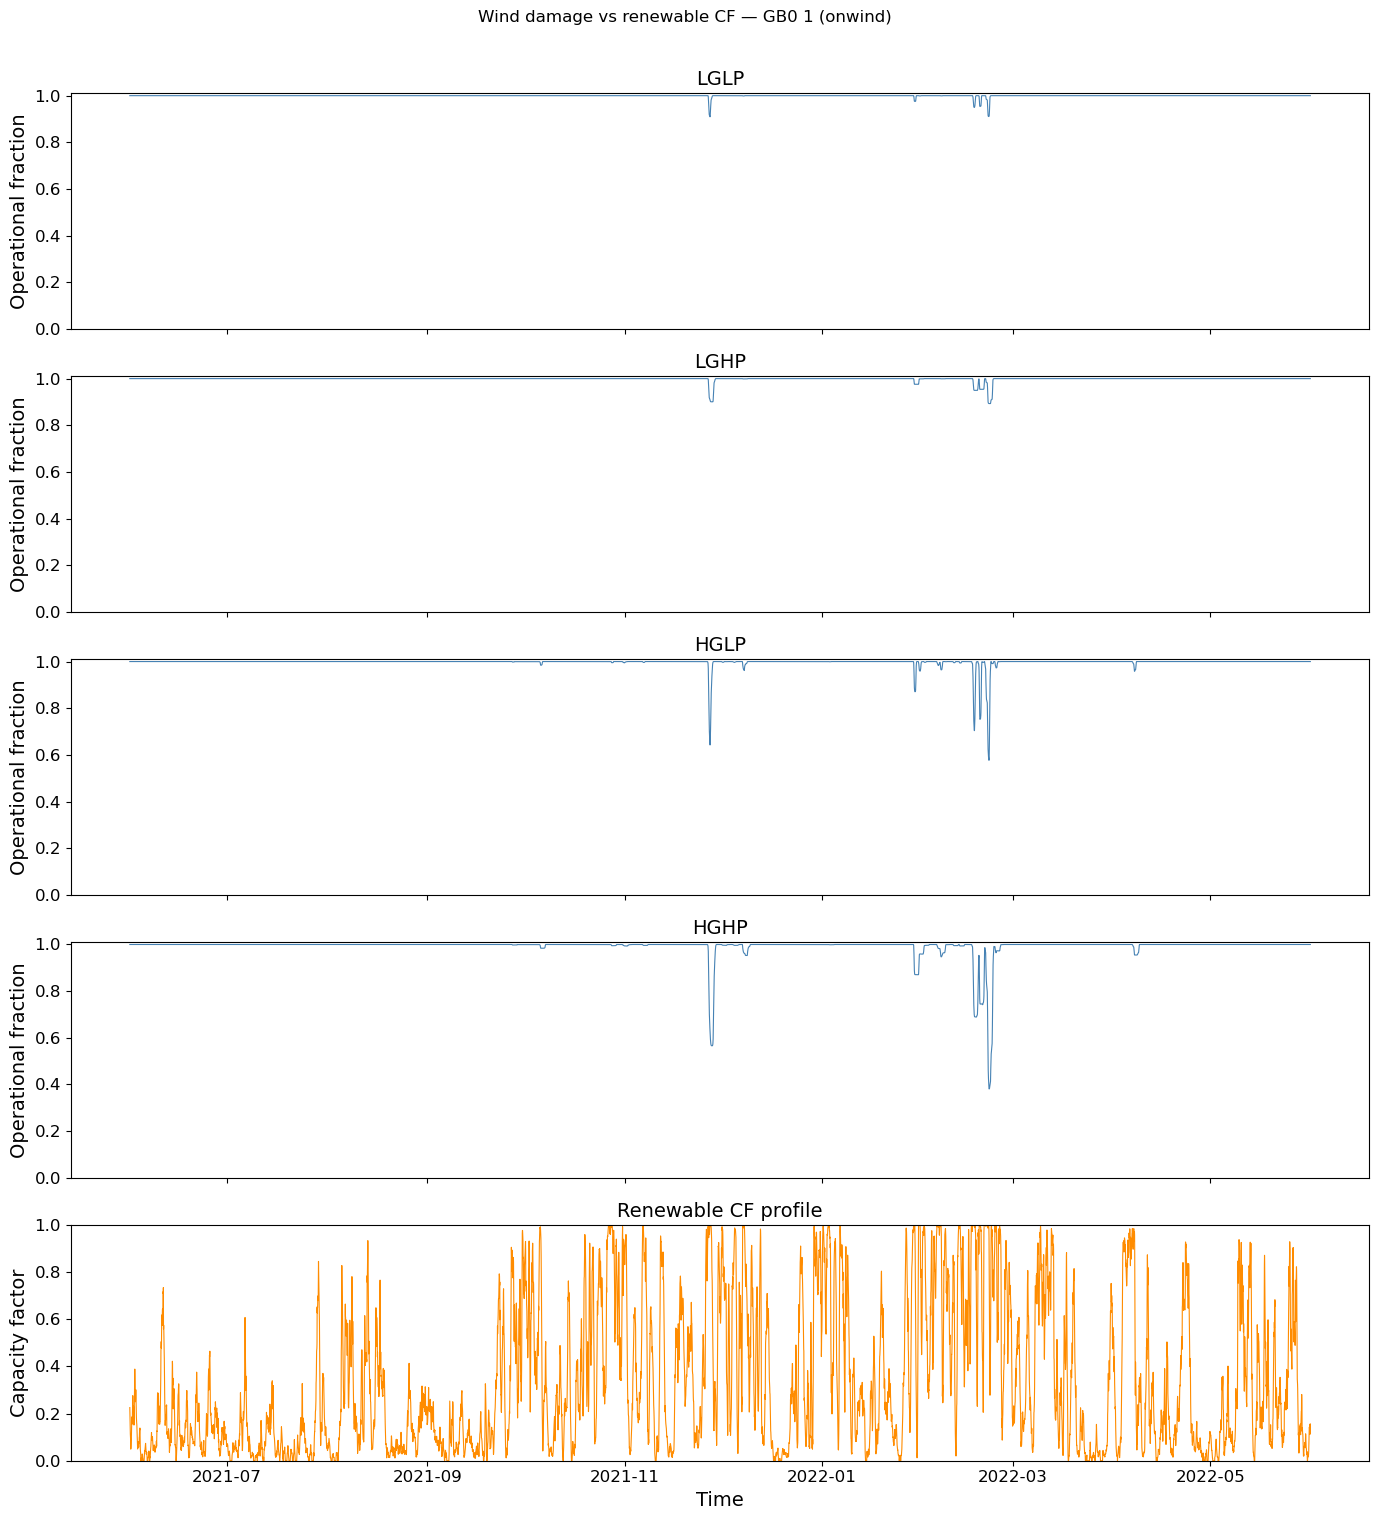

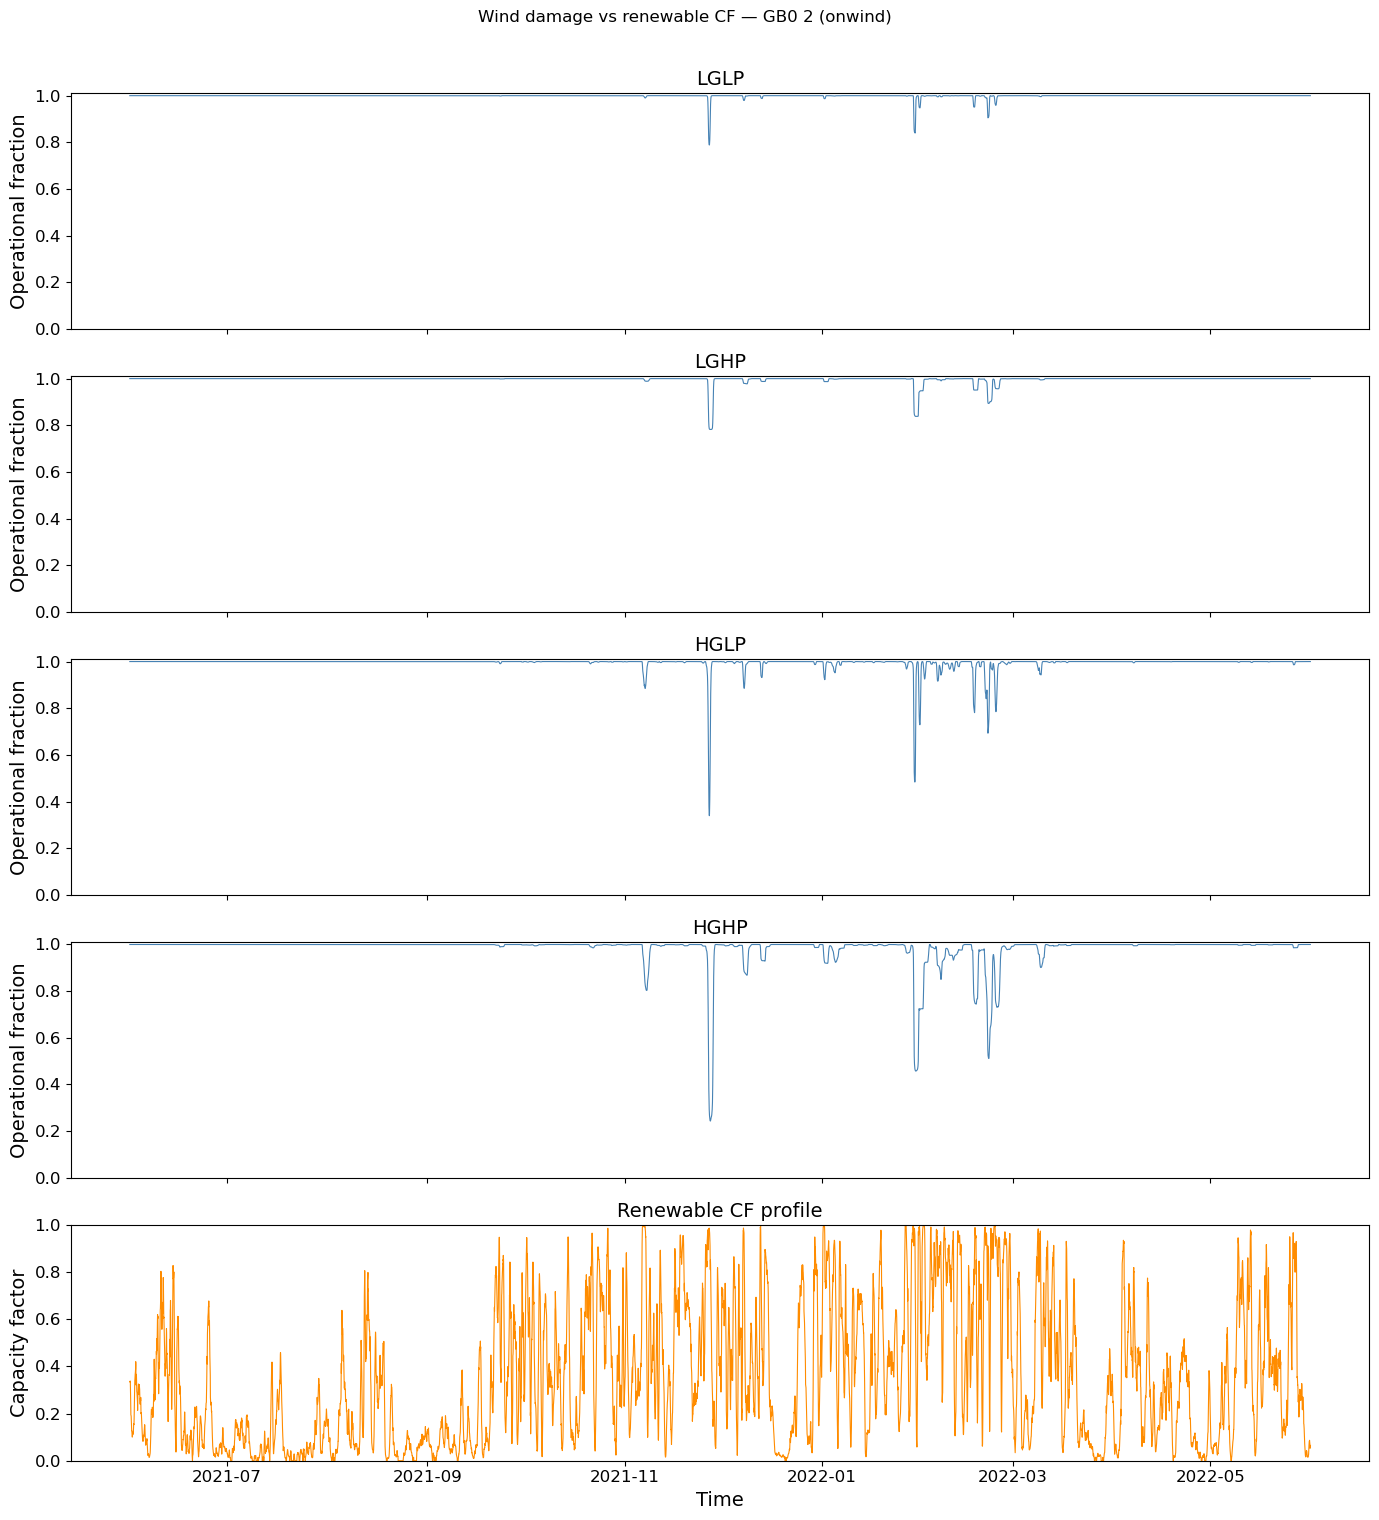

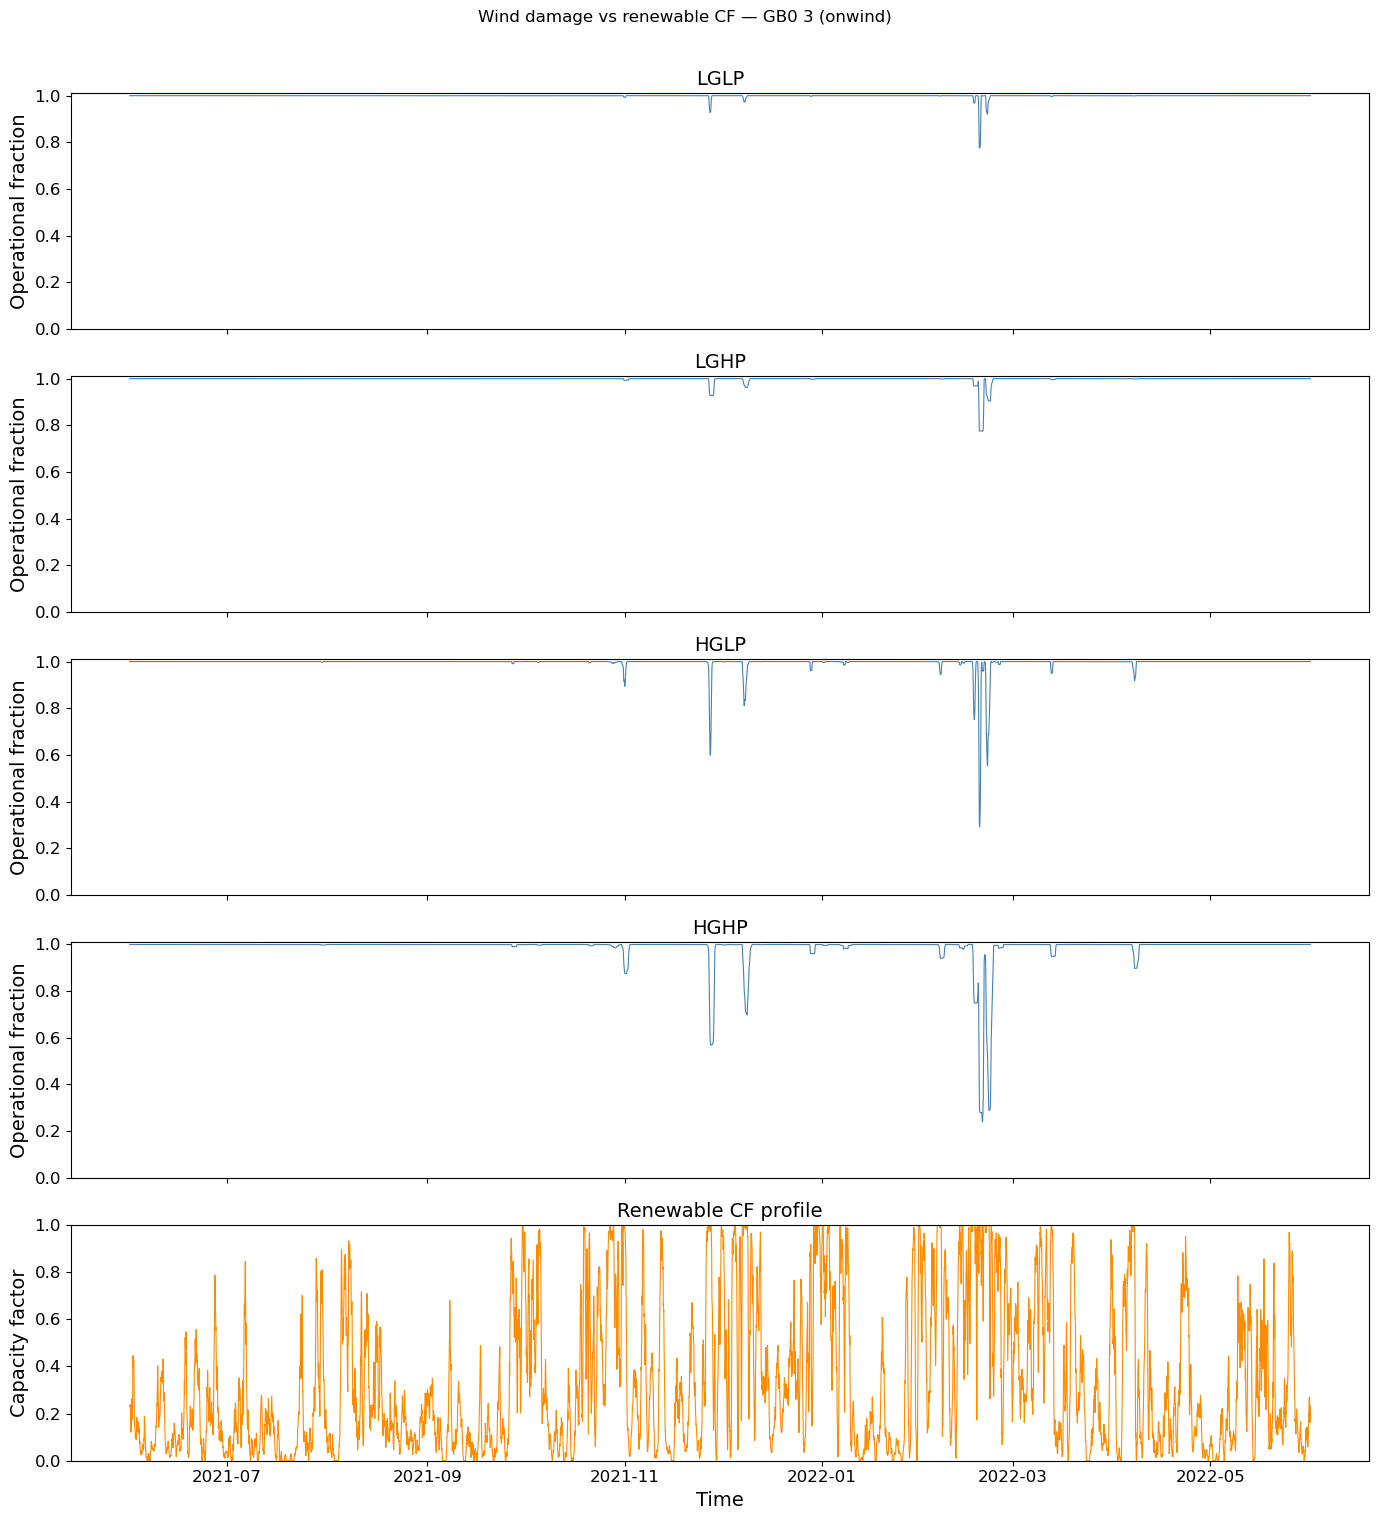

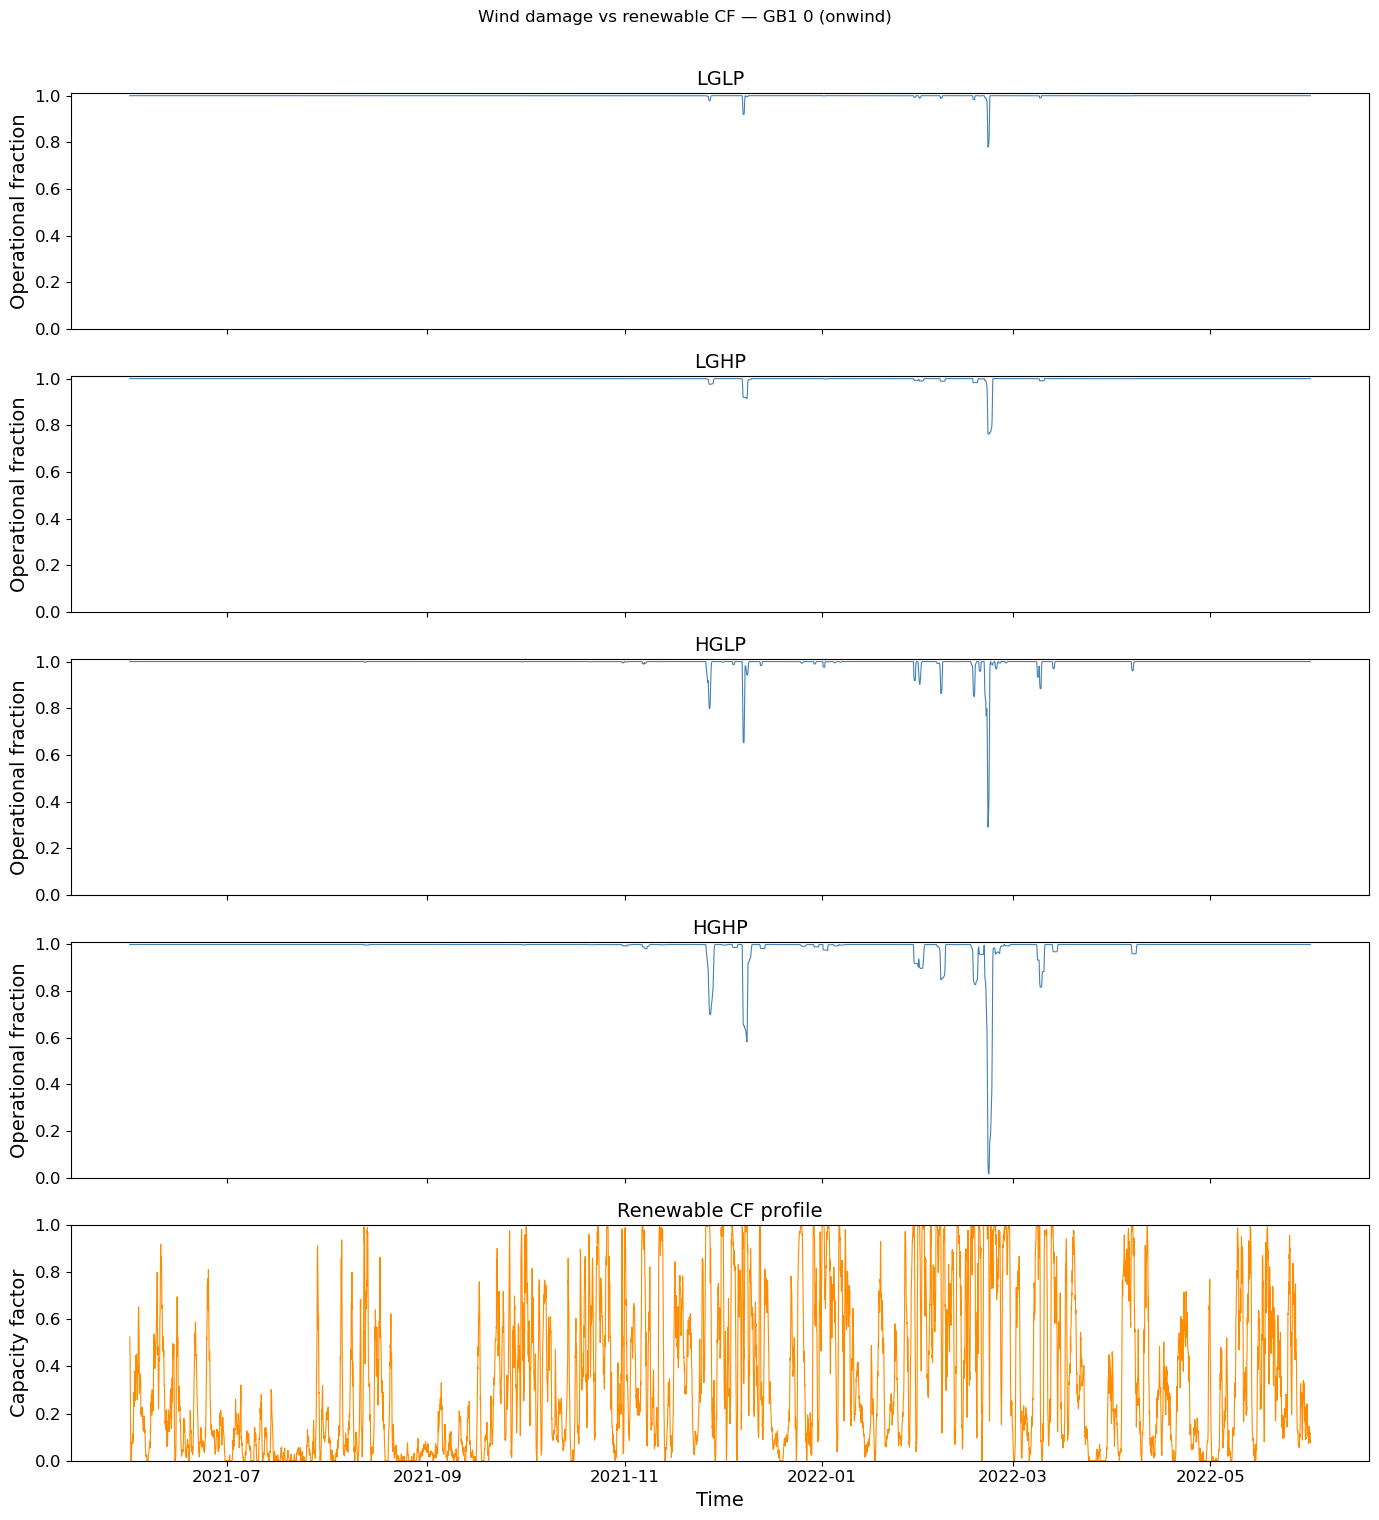

In [26]:
CARRIER  = "onwind"
VARIANTS = ["LGLP", "LGHP", "HGLP", "HGHP"]

_profile_dir = pypsa_eur_root / "resources" / CONFIG_NAME / SCENARIO_VARIANTS[f"dis_{VARIANTS[0]}"]
cf_profile = xr.open_dataset(_profile_dir / f"profile_5_{CARRIER}.nc")["profile"]
buses = cf_profile.bus.values.tolist()

nrows = len(VARIANTS) + 1

for bus in buses:
    fig, axes = plt.subplots(nrows, 1, figsize=(14, 3 * nrows), sharex=True)

    for ax, variant in zip(axes, VARIANTS):
        scenario_dir = pypsa_eur_root / "resources" / CONFIG_NAME / SCENARIO_VARIANTS[f"dis_{variant}"]
        op = 1 - xr.open_dataset(scenario_dir / "damage_profiles" / f"{CARRIER}_damage_5.nc")["profile"]
        ax.plot(op.time.values, op.sel(bus=bus).values,
                color="steelblue", linewidth=0.8, label="1−F_D")
        ax.set_ylabel("Operational fraction")
        ax.set_ylim(0, 1.01)
        ax.set_title(variant)

    axes[-1].plot(cf_profile.time.values, cf_profile.sel(bus=bus).squeeze().values,
                  color="darkorange", linewidth=0.8)
    axes[-1].set_ylabel("Capacity factor")
    axes[-1].set_ylim(0, 1)
    axes[-1].set_title("Renewable CF profile")
    axes[-1].set_xlabel("Time")

    fig.suptitle(f"Wind damage vs renewable CF — {bus} ({CARRIER})", y=1.01)
    plt.tight_layout()
    plt.show()


# Network collection

In [10]:
from pypsa import NetworkCollection

def compute_variant_stats(variants: list) -> pd.DataFrame:
    grouper = ["bus", "carrier", "bus_carrier"]
    diffs = []
    for variant in variants:
        networks_v = {
            "base": pypsa.Network(NETWORK_PATHS[f"base_{variant}"]),
            "cap":  pypsa.Network(NETWORK_PATHS[f"cap_{variant}"]),
            "dis":  pypsa.Network(NETWORK_PATHS[f"dis_{variant}"]),
        }
        nc_v  = NetworkCollection(list(networks_v.values()), index=list(networks_v.keys()))
        stats = nc_v.statistics(groupby=grouper, nice_names=False)
        stats["Expanded Capacity"] = stats["Optimal Capacity"] - stats["Installed Capacity"]
        stats["System Cost"] = nc_v.statistics.system_cost(groupby=grouper, nice_names=False)
        diff  = compute_stats_diff(stats, base="base")
        diff  = format_stats_df(diff, index_names=["techgroup", "network", "bus", "tech", "bus_carrier"])
        diff["variant"] = variant
        diffs.append(diff)
    return pd.concat(diffs, ignore_index=True)

diff_multi = compute_variant_stats(_COST_VARIANTS)



INFO:pypsa.network.io:New version 1.2.4 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.4 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.4 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.4 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.4 available! (Current:

In [14]:
SUP_CARRIERS = [
        'biomass', 'nuclear', 'offwind-ac', 'offwind-dc',
       'onwind', 'solar', 'solar-hsat', 'load_shedding', 'ror']
CHARGE_CARRIERS = ['H2 electrolysis','H2 fuel cell','battery', 'PSH', 'hydro']
WIND_CARRIERS = ["onwind", "offwind-ac", "offwind-dc"]

RE_CARRIERS = ['biomass', 'offwind-ac', 'offwind-dc', 'onwind', 'solar', 'solar-hsat', 'ror', 'biomass']
STOR_CARRIERS = ['H2 fuel cell']

GRID_CARRIERS = [
        'AC', 'DC', 'H2'
        ]
color_map = pypsa.Network(NETWORK_PATHS["base_LGLP"]).carriers.color.to_dict()


INFO:pypsa.network.io:New version 1.2.4 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks


## damaged dispatch networks

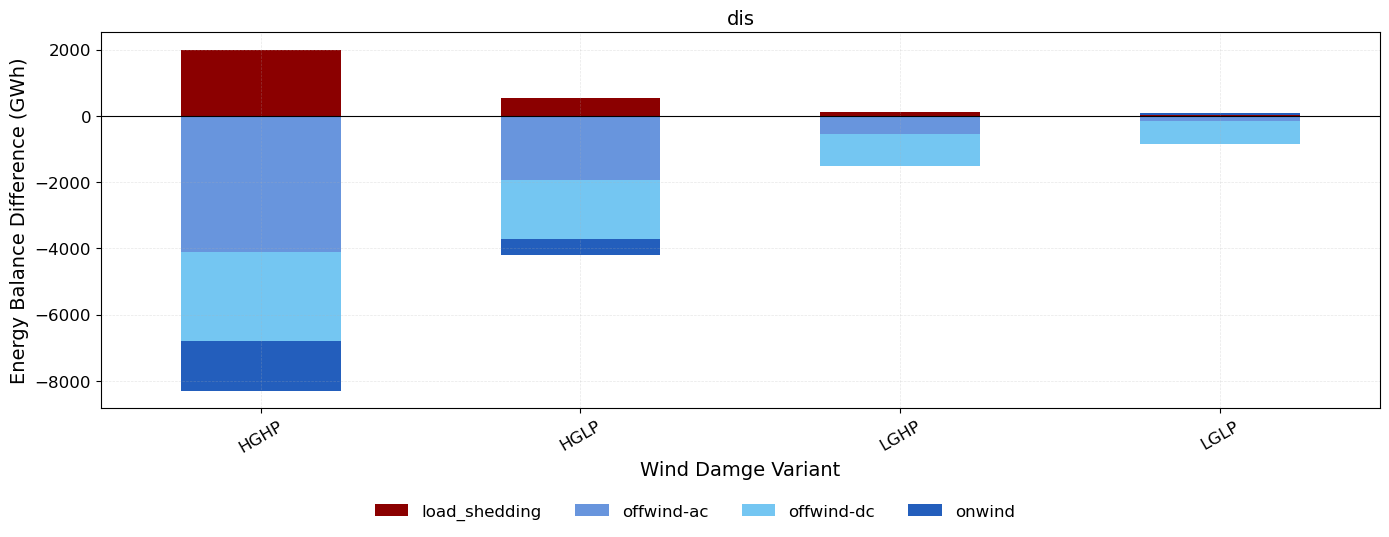

In [12]:
diff_plot = diff_multi[diff_multi["network"] == "dis"].copy()
diff_plot["bus"] = diff_plot["variant"]
WIND_CARRIERS = ["onwind", "offwind-ac", "offwind-dc"]

fig,axes = plot_stats_bar(
    diff_plot[diff_plot["tech"].isin(WIND_CARRIERS + ["load_shedding"])],
    column="energy_balance_diff",
    networks=["dis"],
    multiplier=0.001,
    title="Energy Balance Difference (GWh)",
    color_map=color_map,
    aggregate=False,
)
for ax in axes:
    ax.set_xlabel("Wind Damge Variant")
plt.show()

TypeError: no numeric data to plot

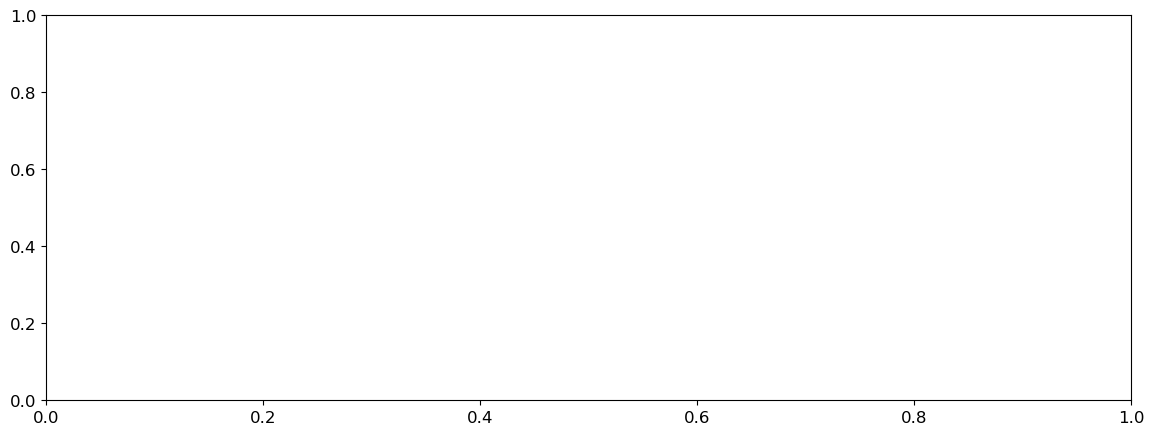

In [18]:
fig,axes = plot_stats_bar(
    diff_plot[diff_plot["tech"].isin(SUP_CARRIERS + CHARGE_CARRIERS)],
    column="installed capacity",
    networks=["base"],
    multiplier=0.001,
    title="Installed Capacity (GW)",
    color_map=color_map,
    aggregate=False,
)
for ax in axes:
    ax.set_xlabel("Wind Damge Variant")
plt.show()

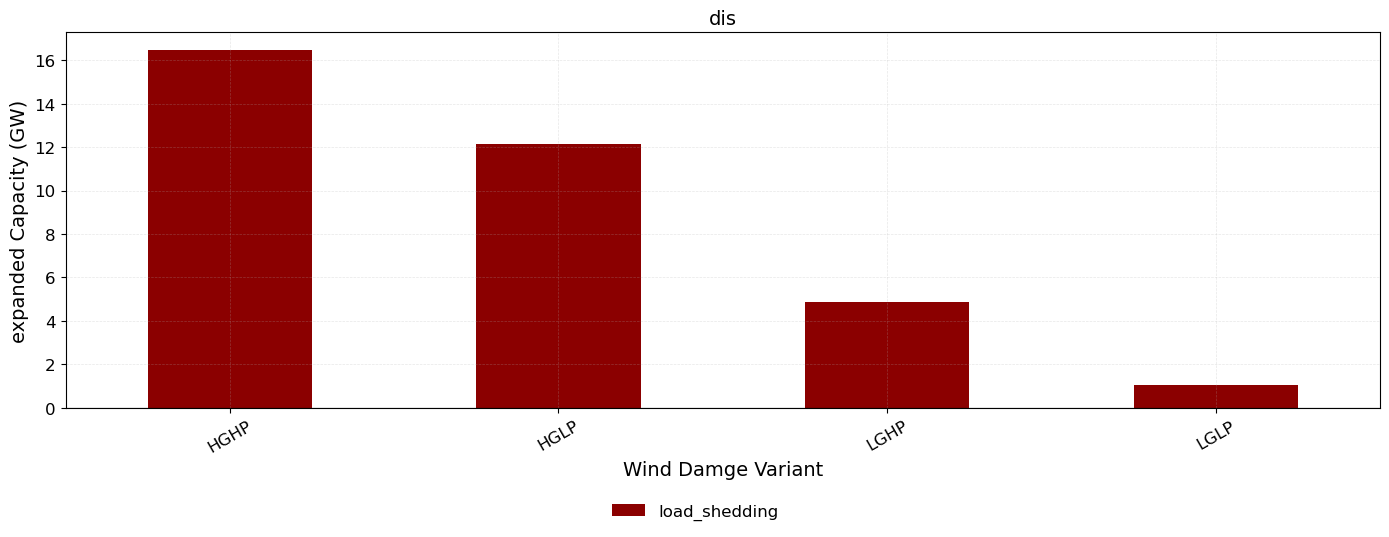

In [15]:
fig,axes = plot_stats_bar(
    diff_plot[diff_plot["tech"].isin(SUP_CARRIERS + CHARGE_CARRIERS)],
    column="expanded capacity",
    networks=["dis"],
    multiplier=0.001,
    title="expanded Capacity (GW)",
    color_map=color_map,
    aggregate=False,
)
for ax in axes:
    ax.set_xlabel("Wind Damge Variant")
plt.show()

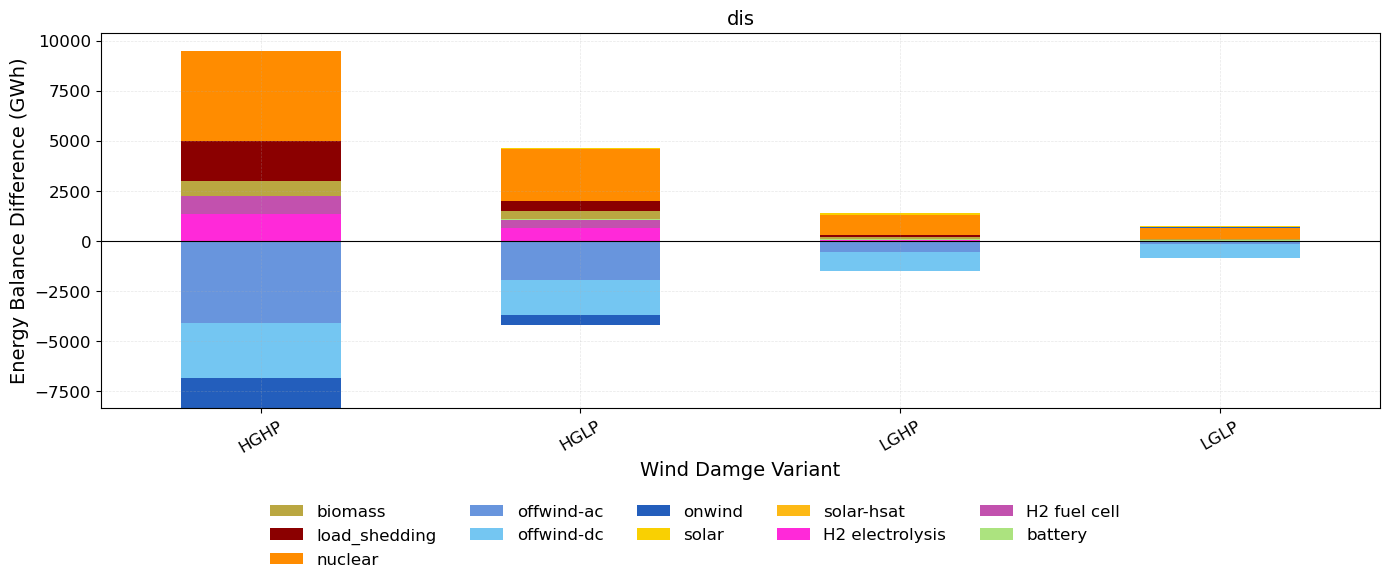

In [13]:
fig,axes = plot_stats_bar(
    diff_plot[diff_plot["tech"].isin(SUP_CARRIERS + CHARGE_CARRIERS)],
    column="energy_balance_diff",
    networks=["dis"],
    multiplier=0.001,
    title="Energy Balance Difference (GWh)",
    color_map=color_map,
    aggregate=False,
)
for ax in axes:
    ax.set_xlabel("Wind Damge Variant")
plt.show()

## damaged capacity networks

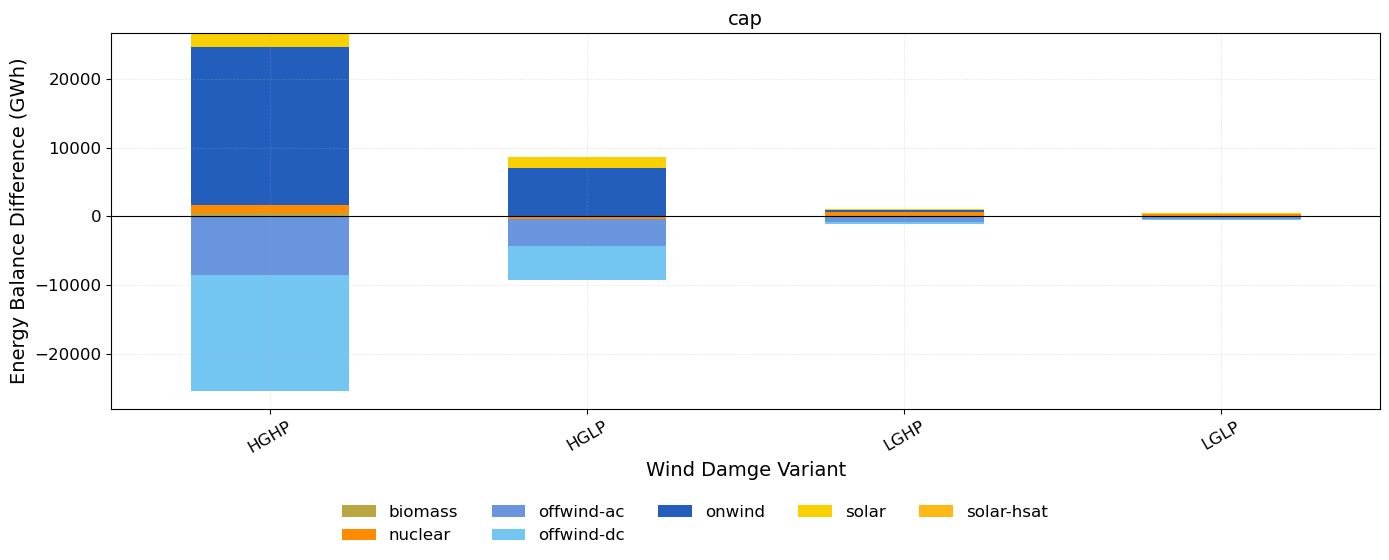

In [153]:
diff_plot = diff_multi[diff_multi["network"] == "cap"].copy()
diff_plot["bus"] = diff_plot["variant"]
WIND_CARRIERS = ["onwind", "offwind-ac", "offwind-dc"]

fig, axes = plot_stats_bar(
    diff_plot[diff_plot["tech"].isin(SUP_CARRIERS)],
    column="energy_balance_diff",
    networks=["cap"],
    multiplier=0.001,
    title="Energy Balance Difference (GWh)",
    color_map=color_map,
    aggregate=False,
)
for ax in axes:
    ax.set_xlabel("Wind Damge Variant")
plt.show()


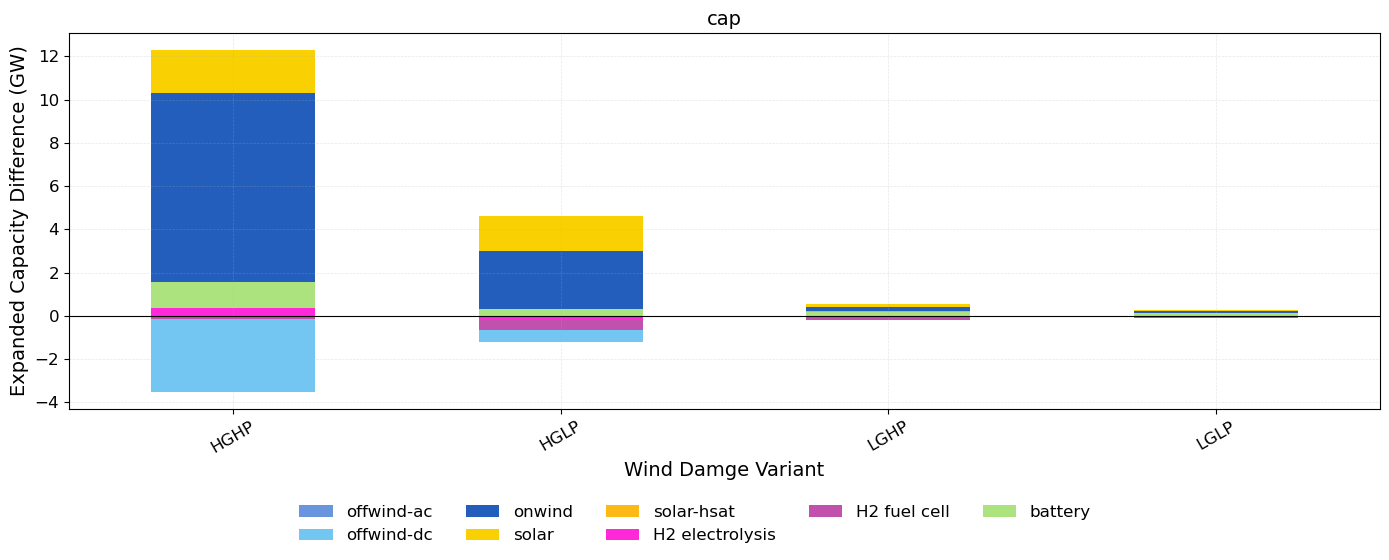

In [154]:
diff_plot = diff_multi[diff_multi["network"] == "cap"].copy()
diff_plot["bus"] = diff_plot["variant"]
WIND_CARRIERS = ["onwind", "offwind-ac", "offwind-dc"]

fig, axes = plot_stats_bar(
    diff_plot[diff_plot["tech"].isin(SUP_CARRIERS + CHARGE_CARRIERS)],
    column="expanded_capacity_diff",
    networks=["cap"],
    multiplier=0.001,
    title="Expanded Capacity Difference (GW)",
    color_map=color_map,
    aggregate=False,
)
for ax in axes:
    ax.set_xlabel("Wind Damge Variant")
plt.show()


In [99]:
diff_multi

,techgroup,network,bus,tech,bus_carrier,optimal capacity,installed capacity,supply,withdrawal,energy balance,...,transmission_diff,capacity_factor_diff,curtailment_diff,capital_expenditure_diff,operational_expenditure_diff,revenue_diff,market_value_diff,expanded_capacity_diff,system_cost_diff,variant
0,Generator,base,GB0 0,CCGT,AC,1.124800e+04,1.124800e+04,0.000000e+00,0.000000e+00,0.000000e+00,...,0.0,0.000000,0.0,0.0,0.0,0.000000e+00,0.000000,0.000000e+00,0.0,LGLP
1,Generator,base,GB0 0,biomass,AC,4.630000e+02,4.630000e+02,1.786376e+06,0.000000e+00,1.786376e+06,...,0.0,0.000000,0.0,0.0,0.0,0.000000e+00,0.000000,0.000000e+00,0.0,LGLP
2,Generator,base,GB0 0,nuclear,AC,3.010000e+03,3.010000e+03,1.242194e+07,0.000000e+00,1.242194e+07,...,0.0,0.000000,0.0,0.0,0.0,0.000000e+00,0.000000,0.000000e+00,0.0,LGLP
3,Generator,base,GB0 0,offwind-ac,AC,6.871002e+03,6.871000e+03,2.855323e+07,0.000000e+00,2.855323e+07,...,0.0,0.000000,0.0,0.0,0.0,0.000000e+00,0.000000,0.000000e+00,0.0,LGLP
4,Generator,base,GB0 0,offwind-dc,AC,6.870000e-03,0.000000e+00,2.052228e+01,0.000000e+00,2.052228e+01,...,0.0,0.000000,0.0,0.0,0.0,0.000000e+00,0.000000,0.000000e+00,0.0,LGLP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
920,Store,dis,GB0 0 H2,H2,H2,6.312866e+06,6.312866e+06,8.445888e+06,8.445888e+06,0.000000e+00,...,0.0,-0.027573,0.0,0.0,0.0,-5.645835e+08,-62.742801,-6.312866e+06,0.0,HGHP
921,Store,dis,GB0 1 H2,H2,H2,1.953566e+06,1.953566e+06,4.509285e+06,4.509285e+06,0.000000e+00,...,0.0,-0.021239,0.0,0.0,0.0,-1.043681e+08,-21.177767,-1.953566e+06,0.0,HGHP
922,Store,dis,GB0 2 H2,H2,H2,2.538887e+05,2.538887e+05,1.206425e+06,1.206425e+06,0.000000e+00,...,0.0,-0.019689,0.0,0.0,0.0,9.292267e+07,77.829875,-2.538887e+05,0.0,HGHP
923,Store,dis,GB0 3 H2,H2,H2,1.831649e+02,1.831649e+02,5.211426e+02,5.211426e+02,0.000000e+00,...,0.0,-0.020650,0.0,0.0,0.0,1.051399e+03,1.662630,-1.831649e+02,0.0,HGHP


# Cost

INFO:pypsa.network.io:New version 1.2.3 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.3 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.3 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.3 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.3 available! (Current:

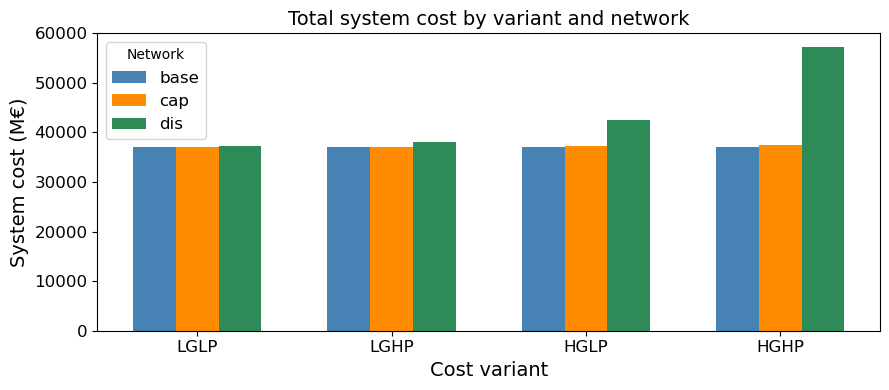

In [155]:
rows = []
for variant in _COST_VARIANTS:
    for network in ["base", "cap", "dis"]:
        n = pypsa.Network(NETWORK_PATHS[f"{network}_{variant}"])
        cost = n.statistics.system_cost(nice_names=False).sum()
        rows.append({"variant": variant, "network": network, "system_cost_M": cost / 1e6})

sc_df = pd.DataFrame(rows)

# ── plot ──────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(9, 4))

networks = ["base", "cap", "dis"]
x        = np.arange(len(_COST_VARIANTS))
width    = 0.22
offsets  = np.linspace(-(len(networks) - 1) / 2, (len(networks) - 1) / 2, len(networks)) * width
colors   = ["steelblue", "darkorange", "seagreen"]

for offset, network, color in zip(offsets, networks, colors):
    vals = [
        sc_df.loc[(sc_df.variant == v) & (sc_df.network == network), "system_cost_M"].iloc[0]
        for v in _COST_VARIANTS
    ]
    ax.bar(x + offset, vals, width=width, label=network, color=color)

ax.set_xticks(x)
ax.set_xticklabels(_COST_VARIANTS)
ax.set_xlabel("Cost variant")
ax.set_ylabel("System cost (M€)")
ax.set_title("Total system cost by variant and network")
ax.legend(title="Network")
fig.tight_layout()
plt.show()


In [157]:
sc_pivot = sc_df.pivot(index="variant", columns="network", values="system_cost_M")

sc_pivot["cap_pct"] = (sc_pivot["cap"] - sc_pivot["base"]) / sc_pivot["base"] * 100
sc_pivot["dis_pct"] = (sc_pivot["dis"] - sc_pivot["base"]) / sc_pivot["base"] * 100

print(sc_pivot[["base", "cap", "cap_pct", "dis", "dis_pct"]].round(2))


network      base       cap  cap_pct       dis  dis_pct
variant                                                
HGHP     37067.38  37427.68     0.97  57144.82    54.16
HGLP     37067.34  37213.91     0.40  42428.36    14.46
LGHP     37067.32  37107.18     0.11  38084.08     2.74
LGLP     37067.35  37078.71     0.03  37203.71     0.37


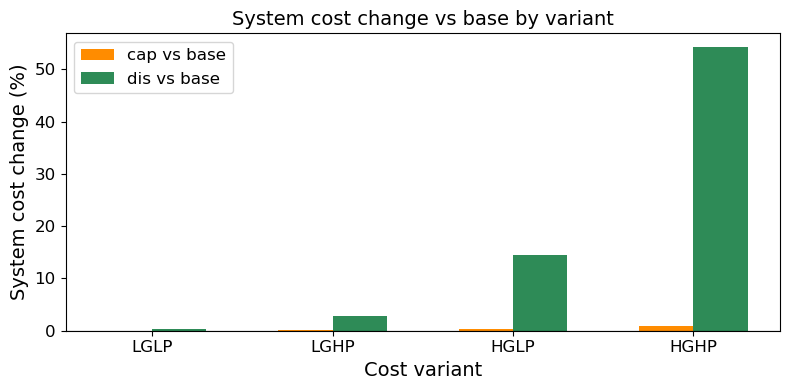

In [158]:
fig, ax = plt.subplots(figsize=(8, 4))
sc_pivot = sc_pivot.reindex(_COST_VARIANTS)

x      = np.arange(len(_COST_VARIANTS))
width  = 0.3

ax.bar(x - width / 2, sc_pivot["cap_pct"], width=width, label="cap vs base", color="darkorange")
ax.bar(x + width / 2, sc_pivot["dis_pct"], width=width, label="dis vs base", color="seagreen")

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(_COST_VARIANTS)
ax.set_xlabel("Cost variant")
ax.set_ylabel("System cost change (%)")
ax.set_title("System cost change vs base by variant")
ax.legend()
fig.tight_layout()
plt.show()


# Damage

INFO:pypsa.network.io:New version 1.2.3 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.3 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.3 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.3 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks


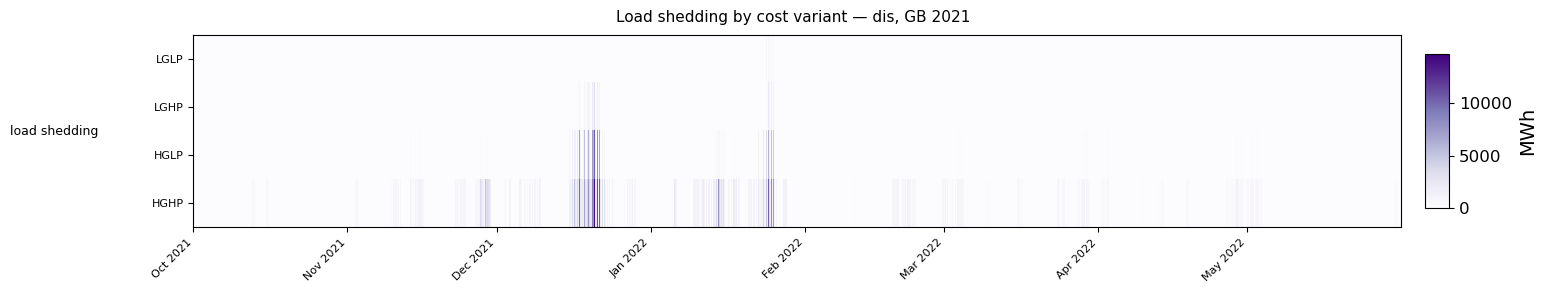

In [ ]:
SNAP_START  = "2021-10-01"
SNAP_END    = "2022-05-31 23:00"
dr = (SNAP_START, SNAP_END)
from plot_combo import plot_combination_profile, format_ts_df

# ── build total load shedding per variant (dis network, buses summed) ─────────
ls_by_variant = {}
for variant in _COST_VARIANTS:
    n = pypsa.Network(NETWORK_PATHS[f"dis_{variant}"])
    ts_eb = format_ts_df(n, stat="energy_balance")
    ls_raw = ts_eb[
        (ts_eb["carrier"] == "load_shedding") &
        (ts_eb["bus_carrier"] == "AC")
    ]
    ls_by_variant[variant] = (
        ls_raw.pivot_table(index="snapshot", columns="bus", values="value", aggfunc="sum")
        .fillna(0)
        .sum(axis=1)
    )

ls_df_variants = pd.DataFrame(ls_by_variant)   # (time × variant)

# ── plot ──────────────────────────────────────────────────────────────────────
fig, axes = plot_combination_profile(
    carrier_groups={},
    components={
        "load shedding": {
            "type": "direct",
            "data": ls_df_variants,
            "cmap": "Purples",
            "unit": "MWh",
        },
    },
    date_range=dr,
    title=f"Load shedding Sensitivity — dis, GB {YEAR}",
)


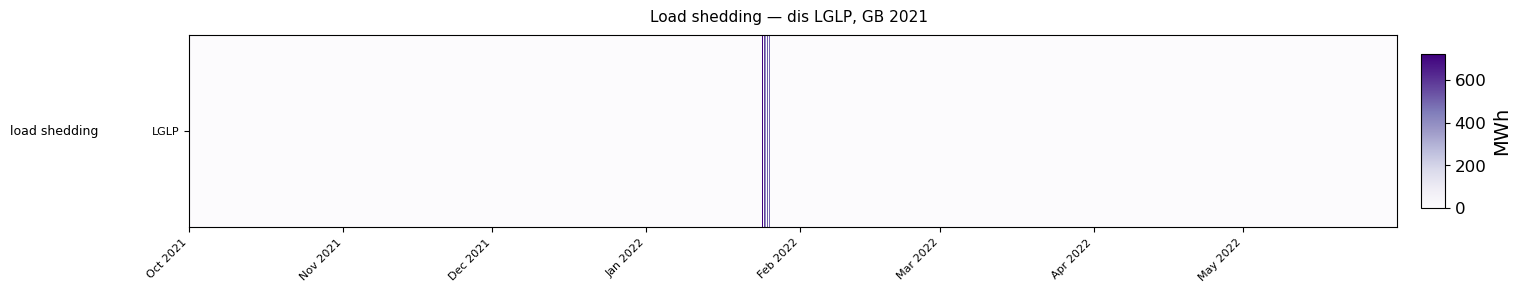

In [165]:
VARIANT = "LGLP"

fig, axes = plot_combination_profile(
    carrier_groups={},
    components={
        "load shedding": {
            "type": "direct",
            "data": ls_df_variants[[VARIANT]],
            "cmap": "Purples",
            "unit": "MWh",
        },
    },
    date_range=dr,
    title=f"Load shedding — dis {VARIANT}, GB {YEAR}",
)


In [173]:
# ── hourly prices per variant (load-weighted average across buses) ────────────
prices_by_variant = {}
for variant in _COST_VARIANTS:
    n = pypsa.Network(NETWORK_PATHS[f"dis_{variant}"])
    prices    = n.buses_t.marginal_price.loc[:, ~n.buses_t.marginal_price.columns.str.contains("H2")]
    load_w    = n.loads_t.p_set.mean().reindex(prices.columns).fillna(0)
    prices_by_variant[variant] = (
        prices.mul(load_w, axis=1).sum(axis=1) / load_w.sum()
    )

prices_df = pd.DataFrame(prices_by_variant)   # (time × variant)


INFO:pypsa.network.io:New version 1.2.3 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.3 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.3 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.3 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks


<Axes: xlabel='snapshot'>

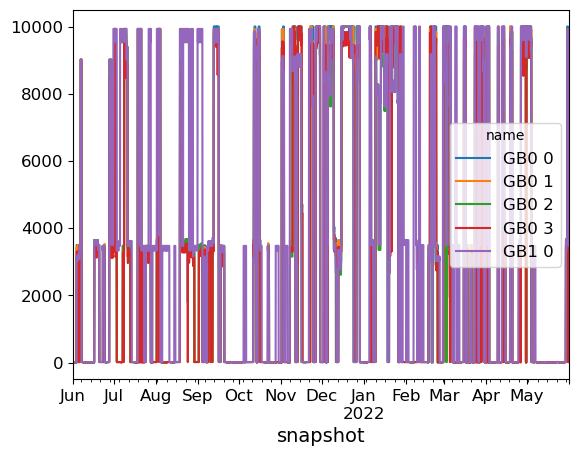

In [174]:
prices.plot()

In [162]:
prices_df

,LGLP,LGHP,HGLP,HGHP
snapshot,,,,
2021-06-01 00:00:00,14.249602,14.249601,14.249679,14.250050
2021-06-01 01:00:00,14.249602,14.249602,14.249681,14.250060
2021-06-01 02:00:00,14.249607,14.249606,14.249722,14.250216
2021-06-01 03:00:00,14.249615,14.249611,14.249772,14.250439
2021-06-01 04:00:00,14.421847,14.421848,14.421916,14.422269
...,...,...,...,...
2022-05-31 19:00:00,125.842420,136.486150,151.955038,152.624903
2022-05-31 20:00:00,125.842446,136.486167,151.955194,152.625675
2022-05-31 21:00:00,125.870805,136.514530,151.983528,152.653857


In [113]:
n.buses_t.marginal_price

name,GB0 0,GB0 1,GB0 2,GB0 3,GB1 0,GB0 0 H2,GB0 1 H2,GB0 2 H2,GB0 3 H2,GB1 0 H2
snapshot,,,,,,,,,,
2021-06-01 00:00:00,14.883928,14.032872,12.882568,14.051935,13.433745,4999.984539,4963.975704,4507.244421,4688.982168,4963.956910
2021-06-01 01:00:00,14.883983,14.032889,12.882402,14.051964,13.433626,4999.984539,4963.975704,4507.244421,4688.980792,4963.956909
2021-06-01 02:00:00,14.884190,14.033023,12.882317,14.052124,13.433588,4999.984539,4963.975704,4507.244421,4688.979412,4963.956908
2021-06-01 03:00:00,14.884397,14.033203,12.882271,14.052314,13.433597,4999.984539,4963.975703,4507.244420,4688.978030,4963.956908
2021-06-01 04:00:00,15.064288,14.202786,13.036622,14.222162,13.433656,4999.984539,4963.975703,4507.244420,4688.976645,4963.956907
...,...,...,...,...,...,...,...,...,...,...
2022-05-31 19:00:00,15.065089,15.830880,15.827995,14.710716,3616.450042,4999.984540,4963.975705,4507.244422,4688.989100,4963.956913
2022-05-31 20:00:00,15.065105,15.848624,15.828941,14.751950,3616.450031,4999.984540,4963.975705,4507.244422,4688.987683,4963.956912
2022-05-31 21:00:00,15.065081,15.848516,15.828857,14.999325,3616.449924,4999.984539,4963.975705,4507.244422,4688.986288,4963.956911


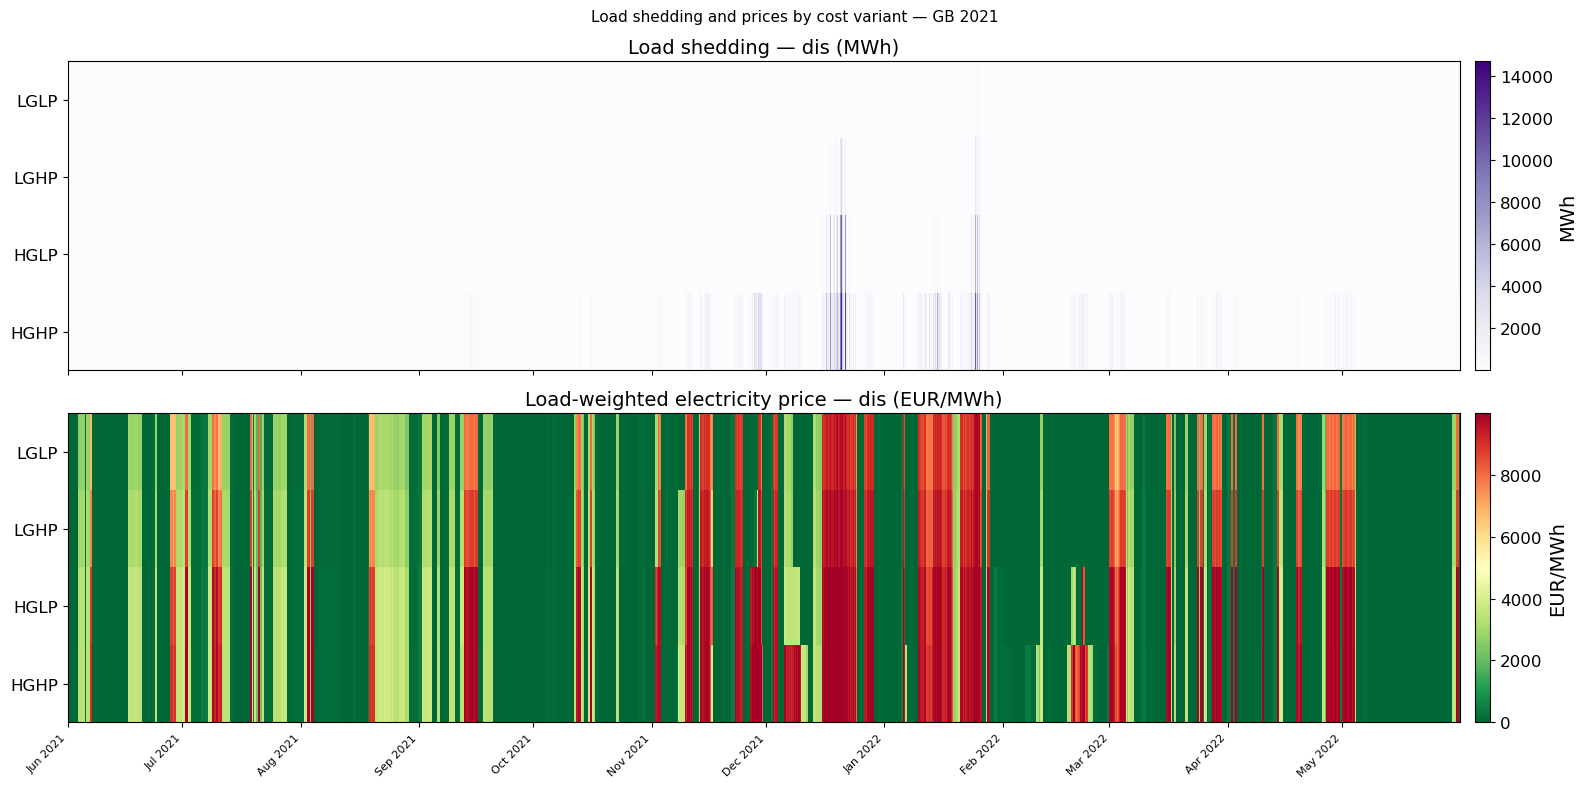

In [163]:
fig, (ax_ls, ax_pr) = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

time_index  = ls_df_variants.index
month_ticks = [i for i in range(len(time_index))
               if i == 0 or time_index[i].month != time_index[i-1].month]
month_labels = [time_index[i].strftime("%b %Y") for i in month_ticks]

# load shedding
im_ls = ax_ls.imshow(ls_df_variants.T.values, aspect="auto", cmap="Purples",
                     interpolation="nearest")
ax_ls.set_yticks(range(len(_COST_VARIANTS)))
ax_ls.set_yticklabels(_COST_VARIANTS)
ax_ls.set_title("Load shedding — dis (MWh)")
fig.colorbar(im_ls, ax=ax_ls, label="MWh", fraction=0.02, pad=0.01)

# prices
vmax  = np.percentile(prices_df.values, 99)
im_pr = ax_pr.imshow(prices_df.T.values, aspect="auto", cmap="RdYlGn_r",
                     interpolation="nearest",
                     norm=plt.Normalize(vmin=0, vmax=vmax))
ax_pr.set_yticks(range(len(_COST_VARIANTS)))
ax_pr.set_yticklabels(_COST_VARIANTS)
ax_pr.set_title("Load-weighted electricity price — dis (EUR/MWh)")
ax_pr.set_xticks(month_ticks)
ax_pr.set_xticklabels(month_labels, rotation=45, ha="right", fontsize=8)
fig.colorbar(im_pr, ax=ax_pr, label="EUR/MWh", fraction=0.02, pad=0.01)

fig.suptitle(f"Load shedding and prices by cost variant — GB {YEAR}", fontsize=11)
fig.tight_layout()
plt.show()


INFO:pypsa.network.io:New version 1.2.3 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.3 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.3 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.3 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks


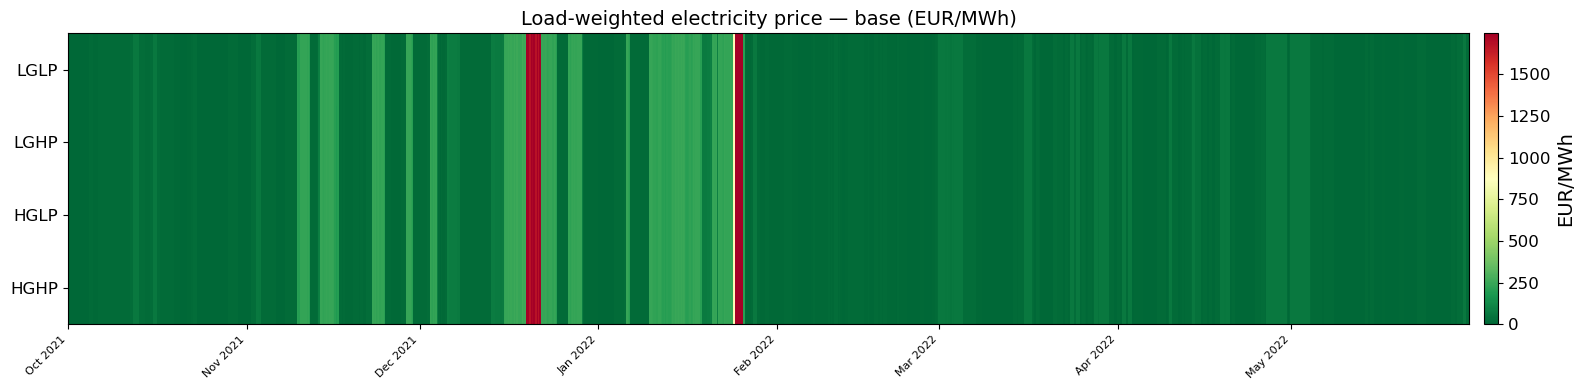

In [166]:
base_prices_by_variant = {}
for variant in _COST_VARIANTS:
    n = pypsa.Network(NETWORK_PATHS[f"base_{variant}"])
    prices = n.buses_t.marginal_price.loc[:, ~n.buses_t.marginal_price.columns.str.contains("H2")]
    load_w = n.loads_t.p_set.mean().reindex(prices.columns).fillna(0)
    base_prices_by_variant[variant] = prices.mul(load_w, axis=1).sum(axis=1) / load_w.sum()

base_prices_df = pd.DataFrame(base_prices_by_variant).loc[dr[0]:dr[1]]

# ── Plot ──────────────────────────────────────────────────────────────────────
time_index  = base_prices_df.index
month_ticks  = [i for i in range(len(time_index))
                if i == 0 or time_index[i].month != time_index[i-1].month]
month_labels = [time_index[i].strftime("%b %Y") for i in month_ticks]

fig, ax = plt.subplots(figsize=(16, 4))
vmax = np.percentile(base_prices_df.values, 99)
im = ax.imshow(base_prices_df.T.values, aspect="auto", cmap="RdYlGn_r",
               interpolation="nearest", norm=plt.Normalize(vmin=0, vmax=vmax))
ax.set_yticks(range(len(_COST_VARIANTS)))
ax.set_yticklabels(_COST_VARIANTS)
ax.set_xticks(month_ticks)
ax.set_xticklabels(month_labels, rotation=45, ha="right", fontsize=8)
ax.set_title(f"Load-weighted electricity price — base (EUR/MWh)")
fig.colorbar(im, ax=ax, label="EUR/MWh", fraction=0.02, pad=0.01)
fig.tight_layout()
plt.show()


INFO:pypsa.network.io:New version 1.2.3 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.3 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.3 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.3 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.3 available! (Current:

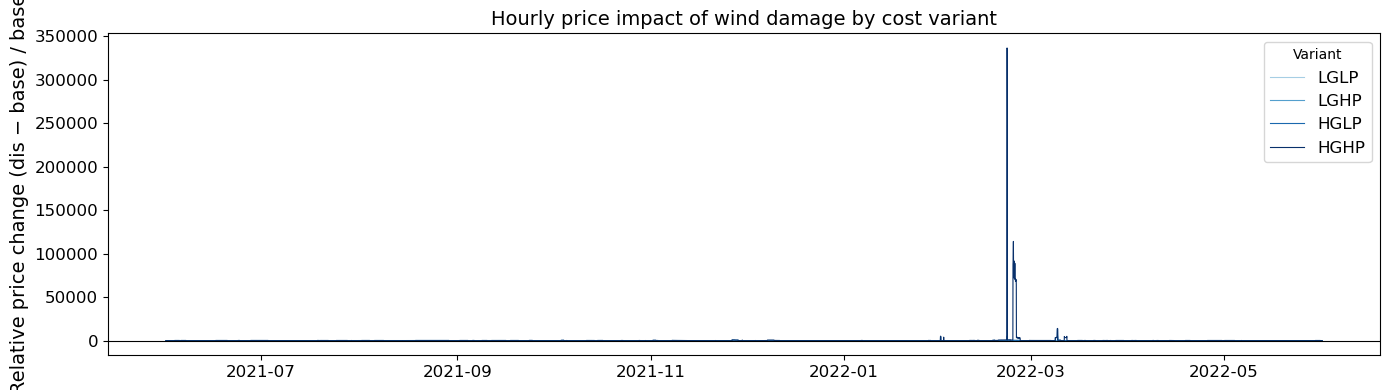

In [119]:
price_diff_by_variant = {}
for variant in _COST_VARIANTS:
    n_dis  = pypsa.Network(NETWORK_PATHS[f"dis_{variant}"])
    n_base = pypsa.Network(NETWORK_PATHS[f"base_{variant}"])

    def load_weighted_price(n):
        prices = n.buses_t.marginal_price.loc[:, ~n.buses_t.marginal_price.columns.str.contains("H2")]
        load_w = n.loads_t.p_set.mean().reindex(prices.columns).fillna(0)
        return prices.mul(load_w, axis=1).sum(axis=1) / load_w.sum()

    p_dis  = load_weighted_price(n_dis)
    p_base = load_weighted_price(n_base)
    price_diff_by_variant[variant] = (p_dis - p_base) / p_base

price_diff_df = pd.DataFrame(price_diff_by_variant)   # (time × variant)

# ── Plot ──────────────────────────────────────────────────────────────────────
cmap = plt.cm.Blues
fig, ax = plt.subplots(figsize=(14, 4))

for i, variant in enumerate(_COST_VARIANTS):
    color = cmap(0.35 + 0.65 * i / (len(_COST_VARIANTS) - 1))
    ax.plot(price_diff_df.index, price_diff_df[variant],
            linewidth=0.8, label=variant, color=color)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Relative price change (dis − base) / base")
ax.set_title("Hourly price impact of wind damage by cost variant")
ax.legend(title="Variant")
fig.tight_layout()
plt.show()


In [ ]:
for carrier in CARRIERS:
    dmg = SCENARIO_DIR / "damage_profiles" / f"{carrier}_damage_{CLUSTERS}.nc"
    pel = compute_potential_energy_loss(dmg, base_net, carrier, date_range=dr, freq="total")
    print(f"{carrier}: {pel['fleet'].iloc[0] / 1e6:.2f} TWh lost")

onwind: 0.13 TWh lost
offwind-ac: 0.45 TWh lost
offwind-dc: 0.29 TWh lost


- fix this code, csv need to be imported and recompute metrics

In [12]:
entsoe_dir = home_root / "pypsa-damage" / "Jahnke_Ardone" / "dataset"

kpis_moy = pd.read_csv(entsoe_dir / "kpis_plant_MOY.csv", sep=";")
kpis_moy = kpis_moy.rename(columns={"period_key": "month"})
kpis_moy["month"] = kpis_moy["month"].astype(int)

gb_onshore  = kpis_moy[(kpis_moy["country"] == "GB") & (kpis_moy["plant_type"] == "Wind Onshore")].sort_values("month")
gb_offshore = kpis_moy[(kpis_moy["country"] == "GB") & (kpis_moy["plant_type"] == "Wind Offshore")].sort_values("month")

# EOH = energy lost / installed capacity (equivalent hours at full output)
for df in [gb_onshore, gb_offshore]:
    df["eoh"] = df["energy_loss_mwh_total"] / df["cap_total_MW"]

# Combined (capacity-weighted)
gb_wind = pd.concat([gb_onshore, gb_offshore])
gb_wind_total = (
    gb_wind.groupby("month")
    .apply(lambda g: pd.Series({
        "energy_loss_mwh_total": g["energy_loss_mwh_total"].sum(),
        "cap_total_MW":          g["cap_total_MW"].sum(),
        "eoh":                   g["energy_loss_mwh_total"].sum() / g["cap_total_MW"].sum(),
    }))
    .reset_index()
)

print("Onshore:\n",  gb_onshore[["month","cap_total_MW","energy_loss_mwh_total","eoh"]])
print("Offshore:\n", gb_offshore[["month","cap_total_MW","energy_loss_mwh_total","eoh"]])
print("Total:\n",    gb_wind_total)


KeyError: 'energy_loss_mwh_total'

In [15]:
# EOH per bus = sum_t(damage(t,bus) × p_max_pu(t,bus))
# i.e. PEL(MWh) / p_nom_opt(MW) — capacity cancels out

eoh_rows = []
for variant in _COST_VARIANTS:
    scenario_dir = pypsa_eur_root / "resources" / CONFIG_NAME / SCENARIO_VARIANTS[f"dis_{variant}"]
    base_net_v   = pypsa.Network(NETWORK_PATHS[f"base_{variant}"])

    for carrier in WIND_CARRIERS:
        dmg_path = scenario_dir / "damage_profiles" / f"{carrier}_damage_{CLUSTERS}.nc"
        if not dmg_path.exists():
            continue
        damage_df, p_max_pu_df, capacities = _load_damage_aligned(dmg_path, base_net_v, carrier)

        # EOH per bus = integral of damage × p_max_pu (in hours)
        eoh_by_bus = (damage_df * p_max_pu_df).sum(axis=0)

        for bus, eoh in eoh_by_bus.items():
            eoh_rows.append({
                "variant": variant,
                "carrier": carrier,
                "bus":     bus,
                "eoh":     eoh,
                "pel_gwh": float(eoh * capacities[bus] / 1e3),
            })

eoh_df = pd.DataFrame(eoh_rows)

# Summary: total EOH per variant × carrier (capacity-weighted across buses)
eoh_summary = (
    eoh_df.groupby(["variant", "carrier"])
    .apply(lambda g: pd.Series({
        "eoh_cap_weighted": (g["eoh"] * g["pel_gwh"]).sum() / g["pel_gwh"].sum(),
        "pel_gwh_total":     g["pel_gwh"].sum(),
    }))
    .reset_index()
)
eoh_summary


INFO:pypsa.network.io:New version 1.2.4 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks


NameError: name '_load_damage_aligned' is not defined

In [20]:
def _load_damage_aligned(
    damage_nc_path: Path,
    base_network: pypsa.Network,
    carrier: str,
    date_range: tuple[str, str] | None = None,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.Series]:
    """
    Load damage profile and align with network generators.

    Returns
    -------
    damage_df   : (time × bus) damage fractions
    p_max_pu_df : (time × bus) p_max_pu time series
    capacities  : bus → p_nom_opt, for buses with p_nom_opt > 0
    """
    damage_df = xr.open_dataset(damage_nc_path)["profile"].to_pandas()
    damage_df.index = pd.to_datetime(damage_df.index)
    if date_range is not None:
        damage_df = damage_df.loc[date_range[0]:date_range[1]]

    gens = base_network.generators[
        (base_network.generators.carrier == carrier) &
        (base_network.generators.p_nom_opt > 0)
    ]
    capacities = pd.Series(gens["p_nom_opt"].values, index=gens["bus"].values)

    common_buses = damage_df.columns.intersection(capacities.index)
    damage_df  = damage_df[common_buses]
    capacities = capacities[common_buses]

    p_max_pu_dict = {}
    for gen_idx, gen in gens[gens["bus"].isin(common_buses)].iterrows():
        if gen_idx in base_network.generators_t.p_max_pu.columns:
            ts = base_network.generators_t.p_max_pu[gen_idx]
        else:
            ts = pd.Series(gen["p_max_pu"], index=damage_df.index)
        ts.index = pd.to_datetime(ts.index)
        p_max_pu_dict[gen["bus"]] = ts.reindex(damage_df.index)

    return damage_df, pd.DataFrame(p_max_pu_dict), capacities


def _aggregate(df: pd.DataFrame, freq: str) -> pd.DataFrame:
    if freq == "h":
        return df
    if freq == "total":
        return pd.DataFrame([df.sum()], index=pd.Index([df.index[0]]))
    return df.resample(freq).sum()


def compute_eoh(
    damage_nc_path: Path,
    base_network: pypsa.Network,
    carrier: str,
    date_range: tuple[str, str] | None = None,
    freq: str = "MS",
    by_bus: bool = False,
) -> pd.DataFrame:
    """
    Equivalent outage hours — count of hours with damage > 0 per period.

    Parameters
    ----------
    freq : "h" | "W" | "MS" | "total"
    by_bus : True → one column per bus; False → capacity-weighted fleet column.

    Returns
    -------
    pd.DataFrame  index=time periods, columns=buses or ["fleet"]
    """
    damage_df, _, capacities = _load_damage_aligned(
        damage_nc_path, base_network, carrier, date_range
    )
    eoh_df = _aggregate(damage_df, freq)

    if by_bus:
        return eoh_df

    fleet = eoh_df.mul(capacities, axis=1).sum(axis=1) / capacities.sum()
    return fleet.rename("fleet").to_frame()


def compute_potential_energy_loss(
    damage_nc_path: Path,
    base_network: pypsa.Network,
    carrier: str,
    date_range: tuple[str, str] | None = None,
    freq: str = "MS",
    by_bus: bool = False,
) -> pd.DataFrame:
    """
    Potential energy loss (MWh) — energy that would have been generated without damage.

    PEL = damage_fraction × p_max_pu × p_nom_opt, aggregated per period.

    Parameters
    ----------
    freq : "h" | "W" | "MS" | "total"
    by_bus : True → one column per bus; False → fleet total (sum across buses).

    Returns
    -------
    pd.DataFrame  index=time periods, columns=buses or ["fleet"]
    """
    damage_df, p_max_pu_df, capacities = _load_damage_aligned(
        damage_nc_path, base_network, carrier, date_range
    )
    pel_df = _aggregate(damage_df * p_max_pu_df * capacities, freq)

    if by_bus:
        return pel_df

    return pel_df.sum(axis=1).rename("fleet").to_frame()


In [167]:
# --- Data preparation ---
pel_by_variant = {}
for variant in _COST_VARIANTS:
    scenario_dir = pypsa_eur_root / "resources" / CONFIG_NAME / SCENARIO_VARIANTS[f"dis_{variant}"]
    base_net_v   = pypsa.Network(NETWORK_PATHS[f"base_{variant}"])
    pel_by_variant[variant] = {
        carrier: compute_potential_energy_loss(
            scenario_dir / "damage_profiles" / f"{carrier}_damage_{CLUSTERS}.nc",
            base_net_v, carrier, date_range=dr, freq="h", by_bus=True,
        )
        for carrier in CARRIERS
    }


INFO:pypsa.network.io:New version 1.2.3 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.3 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.3 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.3 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks


In [168]:
ls_by_variant = {}
for variant in _COST_VARIANTS:
    n = pypsa.Network(NETWORK_PATHS[f"dis_{variant}"])
    ts_eb = format_ts_df(n, stat="energy_balance")
    ls_raw = ts_eb[
        (ts_eb["carrier"] == "load_shedding") &
        (ts_eb["bus_carrier"] == "AC")
    ]
    ls_df = ls_raw.pivot_table(index="snapshot", columns="bus", values="value", aggfunc="sum")
    ls_by_variant[variant] = ls_df.where(ls_df > 0.01, 0.0)


INFO:pypsa.network.io:New version 1.2.3 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.3 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.3 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.3 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks


In [123]:
from functools import reduce

def build_storage_dict(nc, network):
    battery = nc.storage_units_t.state_of_charge[network]
    battery.columns = battery.columns.str.rsplit(" ", n=1).str[0]  # "GB0 0"
    battery = battery.T.groupby(level=0).sum().T

    h2 = nc.stores_t.e.filter(like="H2")[network]
    h2.columns = h2.columns.str.rsplit(" ", n=1).str[0]
    h2 = h2.T.groupby(level=0).sum().T

    return {"battery": battery, "H2": h2}

def _apply_carrier_groups(data_dict: dict, carrier_groups: dict) -> dict:
    result = {}
    for label, spec in carrier_groups.items():
        carriers = [spec] if isinstance(spec, str) else spec
        parts = [data_dict[c] for c in carriers if c in data_dict]
        if parts:
            result[label] = reduce(lambda a, b: a.add(b, fill_value=0), parts)
    return result

def build_eb_diff_by_bus(
    ts_diff: pd.DataFrame,
    carrier: str,
    network: str,
) -> pd.DataFrame:
    """Pivot energy balance diff for one carrier/network to (time × bus)."""
    mask = (
        (ts_diff["carrier"] == carrier) &
        (ts_diff["network"] == network) &
        (ts_diff["bus_carrier"] == "AC")
    )
    raw = ts_diff[mask]
    return raw.pivot_table(index="snapshot", columns="bus", values="value_diff", aggfunc="sum")




In [124]:
from plot_combo import (
    plot_combination_profile,
    format_ts_df, format_ts_diff_df,
    build_eb_diff_by_bus, build_storage_dict,
)

INFO:pypsa.network.io:New version 1.2.3 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.3 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks


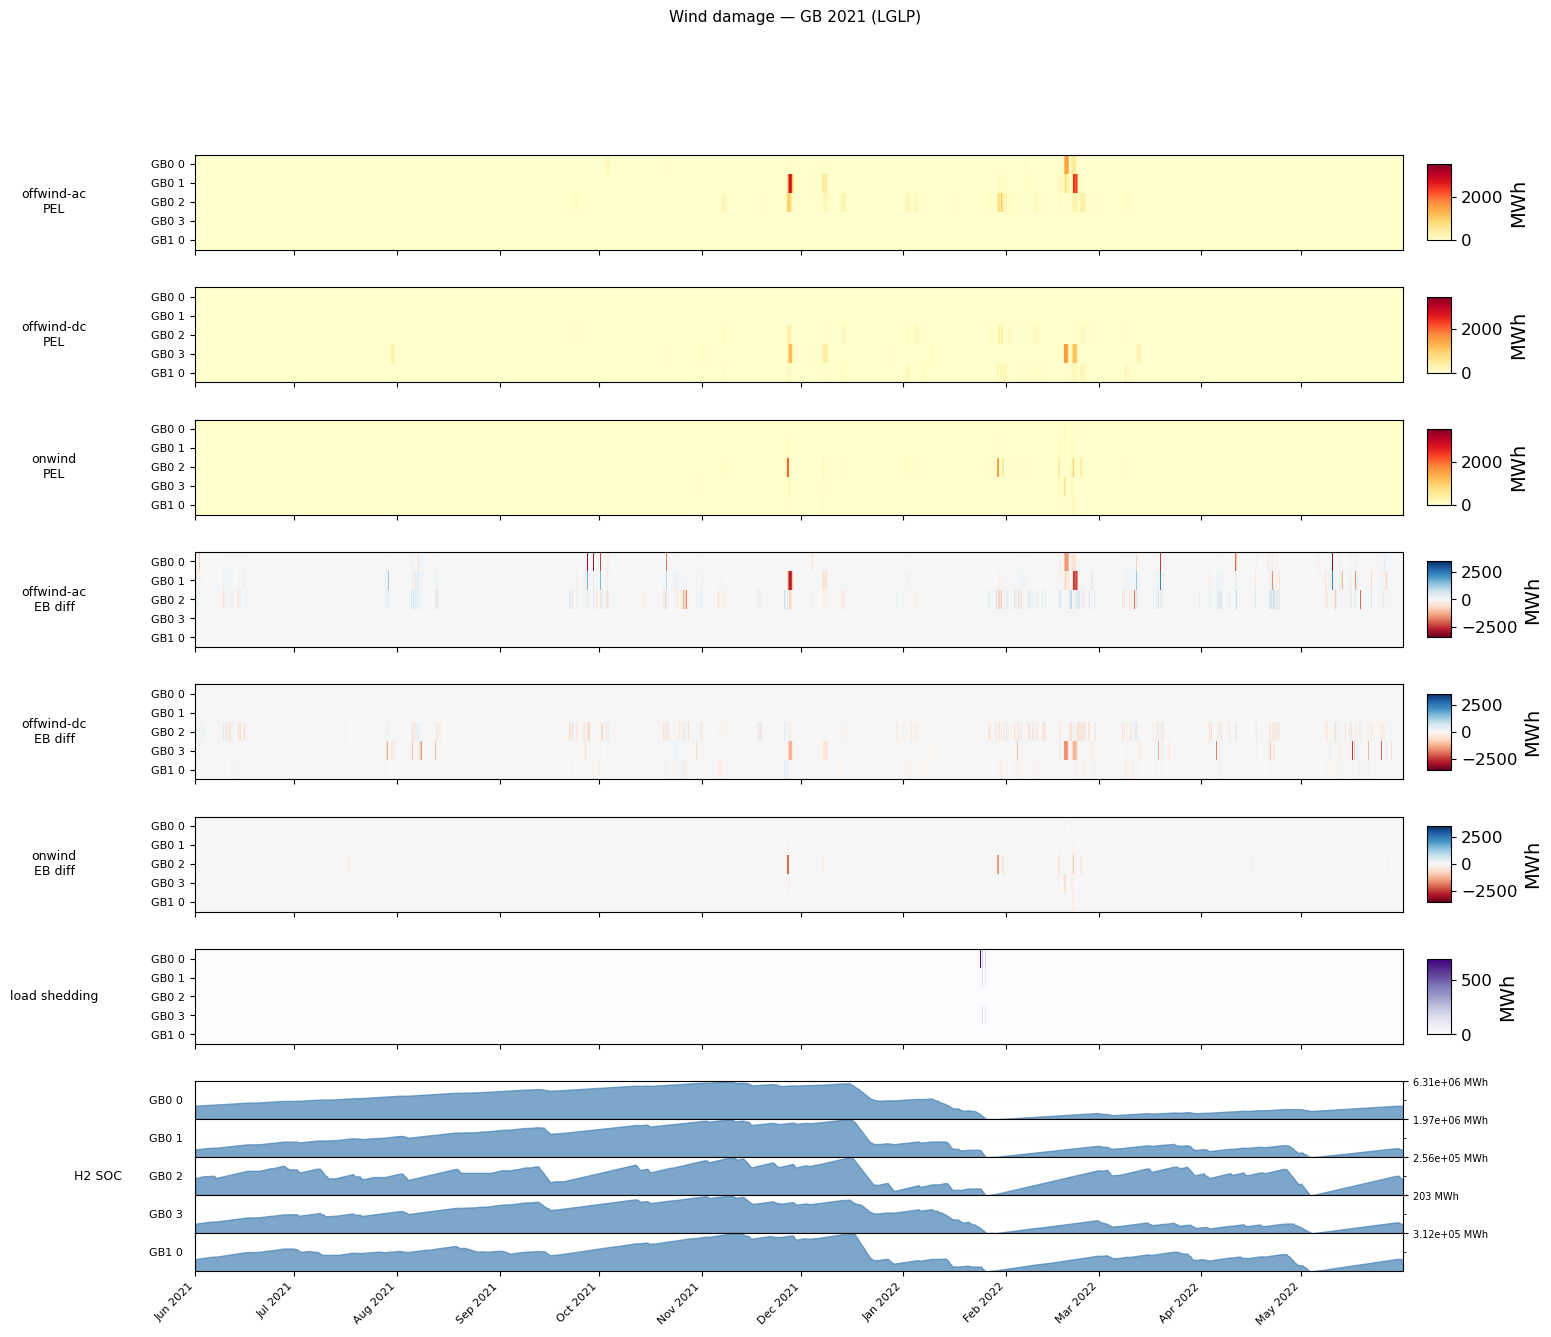

In [170]:
SNAP_START  = "2021-06-01"
SNAP_END    = "2022-05-31 23:00"
dr = (SNAP_START, SNAP_END)
VARIANT = "LGLP"   # LGLP | LGHP | HGLP | HGHP

networks = {
    "base": pypsa.Network(NETWORK_PATHS[f"base_{VARIANT}"]),
    "dis":  pypsa.Network(NETWORK_PATHS[f"dis_{VARIANT}"]),
}
nc = NetworkCollection(list(networks.values()), index=list(networks.keys()))
base_net = networks["base"]
SCENARIO_DIR = pypsa_eur_root / "resources" / CONFIG_NAME / SCENARIO_VARIANTS[f"dis_{VARIANT}"]

base = "base"
scen = "dis"

# ── Statistics diffs ──────────────────────────────────────────────────────────
ts_diff = format_ts_diff_df(networks, stat="energy_balance", base=base)

EXCLUDE_gen_storage = ["coal", "ocgt", "ccgt"]
ts_eb  = format_ts_df(networks[scen], stat="energy_balance")
ts_eb  = ts_eb[~ts_eb["carrier"].isin(EXCLUDE_gen_storage)]
ls_raw = ts_eb[
    (ts_eb["carrier"] == "load_shedding") &
    (ts_eb["bus_carrier"] == "AC")
]
ls_df = ls_raw.pivot_table(index="snapshot", columns="bus", values="value", aggfunc="sum").fillna(0)
ls_df[ls_df < 0.01] = 0

WIND_CARRIERS = ["offwind-ac", "offwind-dc", "onwind"]
pel_dict_win = {
    c: compute_potential_energy_loss(
        SCENARIO_DIR / "damage_profiles" / f"{c}_damage_{CLUSTERS}.nc",
        base_net, c, date_range=dr, freq="h", by_bus=True
    )
    for c in WIND_CARRIERS
}

storage_dict = build_storage_dict(nc, scen)

fig, axes = plot_combination_profile(
    carrier_groups={c: c for c in WIND_CARRIERS},
    components={
        "PEL": {
            "type": "carrier_dict", "data": pel_dict_win,
            "cmap": "YlOrRd", "unit": "MWh", "vmax_group": "wind",
        },
        "EB diff": {
            "type": "ts_diff", "data": ts_diff, "network": scen,
            "cmap": "RdBu", "symmetric": True, "unit": "MWh", "vmax_group": "wind",
        },
        "load shedding": {
            "type": "direct", "data": ls_df,
            "cmap": "Purples", "unit": "MWh",
        },
        "H2 SOC": {
            "type": "direct", "data": storage_dict["H2"],
            "render": "area", "unit": "MWh", "row_height": 0.6,
        },
    },
    aggregate_buses=False,
    date_range=dr,
    title=f"Wind damage — GB {YEAR} ({VARIANT})",
)



INFO:pypsa.network.io:New version 1.2.3 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.3 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks


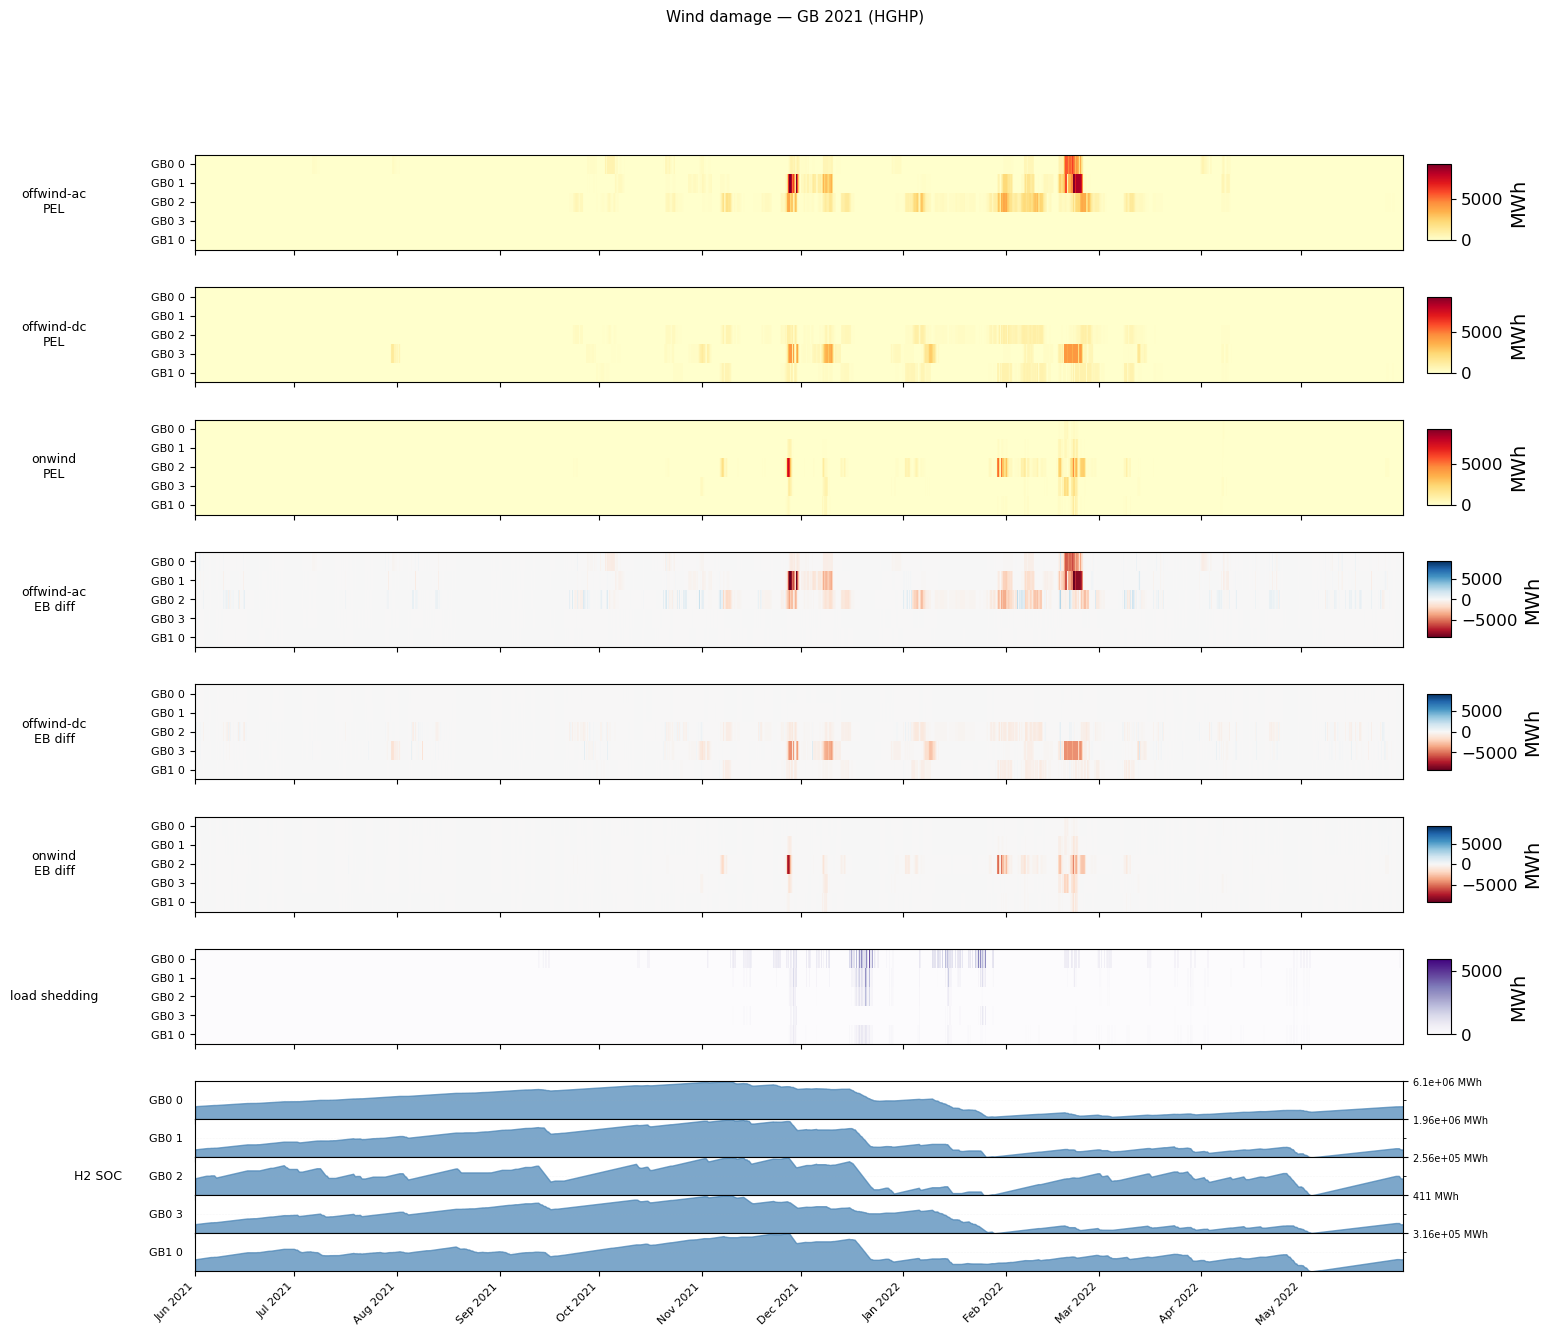

In [171]:
SNAP_START  = "2021-06-01"
SNAP_END    = "2022-05-31 23:00"
dr = (SNAP_START, SNAP_END)
VARIANT = "HGHP"   # LGLP | LGHP | HGLP | HGHP

networks = {
    "base": pypsa.Network(NETWORK_PATHS[f"base_{VARIANT}"]),
    "dis":  pypsa.Network(NETWORK_PATHS[f"dis_{VARIANT}"]),
}
nc = NetworkCollection(list(networks.values()), index=list(networks.keys()))
base_net = networks["base"]
SCENARIO_DIR = pypsa_eur_root / "resources" / CONFIG_NAME / SCENARIO_VARIANTS[f"dis_{VARIANT}"]

base = "base"
scen = "dis"

# ── Statistics diffs ──────────────────────────────────────────────────────────
ts_diff = format_ts_diff_df(networks, stat="energy_balance", base=base)

EXCLUDE_gen_storage = ["coal", "ocgt", "ccgt"]
ts_eb  = format_ts_df(networks[scen], stat="energy_balance")
ts_eb  = ts_eb[~ts_eb["carrier"].isin(EXCLUDE_gen_storage)]
ls_raw = ts_eb[
    (ts_eb["carrier"] == "load_shedding") &
    (ts_eb["bus_carrier"] == "AC")
]
ls_df = ls_raw.pivot_table(index="snapshot", columns="bus", values="value", aggfunc="sum").fillna(0)
ls_df[ls_df < 0.01] = 0

WIND_CARRIERS = ["offwind-ac", "offwind-dc", "onwind"]
pel_dict_win = {
    c: compute_potential_energy_loss(
        SCENARIO_DIR / "damage_profiles" / f"{c}_damage_{CLUSTERS}.nc",
        base_net, c, date_range=dr, freq="h", by_bus=True
    )
    for c in WIND_CARRIERS
}

storage_dict = build_storage_dict(nc, scen)

fig, axes = plot_combination_profile(
    carrier_groups={c: c for c in WIND_CARRIERS},
    components={
        "PEL": {
            "type": "carrier_dict", "data": pel_dict_win,
            "cmap": "YlOrRd", "unit": "MWh", "vmax_group": "wind",
        },
        "EB diff": {
            "type": "ts_diff", "data": ts_diff, "network": scen,
            "cmap": "RdBu", "symmetric": True, "unit": "MWh", "vmax_group": "wind",
        },
        "load shedding": {
            "type": "direct", "data": ls_df,
            "cmap": "Purples", "unit": "MWh",
        },
        "H2 SOC": {
            "type": "direct", "data": storage_dict["H2"],
            "render": "area", "unit": "MWh", "row_height": 0.6,
        },
    },
    aggregate_buses=False,
    date_range=dr,
    title=f"Wind damage — GB {YEAR} ({VARIANT})",
)



# ENTSOE

In [26]:
import pandas as pd

entsoe_dir = home_root / "pypsa-damage" / "Jahnke_Ardone" / "dataset"

kpis_moy = pd.read_csv(entsoe_dir / "kpis_plant_MOY.csv", sep=";")

cols = ["country", "month", "n_units", "cap_total_MW", "UOH", "EUDH",
        "wRR_uo_h", "wRR_eud_h", "N_UO", "N_EUO", "wEUOR", "D_h"]

def build_tech_df(kpis_moy, plant_type):
    df = kpis_moy[kpis_moy["plant_type"] == plant_type].copy()
    df = df.rename(columns={"period_key": "month"})
    df["month"] = df["month"].astype(int)
    df = df[cols].copy()

    df["avg_uo_d"]    = df["UOH"]  / (df["N_UO"] * 24)
    df["avg_eud_d"]   = df["EUDH"] / ((df["N_EUO"] - df["N_UO"]) * 24)
    df["wMTTR_uo_d"]  = 1 / (df["wRR_uo_h"] * 24)
    df["wMTTR_eud_d"] = 1 / (df["wRR_eud_h"] * 24)
    df["equiv_outage_h_per_unit"] = df["wEUOR"] * (df["D_h"] / df["n_units"])
    df["energy_loss_mwh_total"]   = df["equiv_outage_h_per_unit"] * df["cap_total_MW"]
    return df

wind_onshore_df  = build_tech_df(kpis_moy, "Wind Onshore").query("country == 'GB'")
wind_offshore_df = build_tech_df(kpis_moy, "Wind Offshore").query("country == 'GB'")



In [27]:
wind_onshore_df

,country,month,n_units,cap_total_MW,UOH,EUDH,wRR_uo_h,wRR_eud_h,N_UO,N_EUO,wEUOR,D_h,avg_uo_d,avg_eud_d,wMTTR_uo_d,wMTTR_eud_d,equiv_outage_h_per_unit,energy_loss_mwh_total
936,GB,1,22.0,3102.9091,73.0000,1.1229,0.4092,0.1989,0.8182,1.0909,0.0041,16225.8182,3.717510,0.171571,0.101825,0.209486,3.023902,9382.894531
937,GB,2,22.0,3102.9091,4.1818,2.0873,0.1356,0.5552,0.3636,0.8182,0.0005,14832.8182,0.479213,0.191313,0.307276,0.075048,0.337110,1046.020149
938,GB,3,22.0,3102.9091,41.4545,25.8030,0.0306,0.0237,0.4545,0.7273,0.0055,16259.7273,3.800376,3.941074,1.361656,1.758087,4.064932,12613.113951
939,GB,4,22.0,3102.9091,20.0000,6.3472,0.0207,0.5048,0.4545,0.6364,0.0021,15648.8182,1.833517,1.453912,2.012882,0.082541,1.493751,4634.973038
940,GB,5,22.0,3102.9091,6.0000,0.4979,0.4487,0.1714,0.4545,0.6364,0.0004,16217.7273,0.550055,0.114051,0.092861,0.243096,0.294868,914.947884
941,GB,6,22.0,3102.9091,14.4545,7.5517,0.3092,0.1106,0.6364,0.9091,0.0019,15524.6364,0.946372,1.153847,0.134756,0.376733,1.340764,4160.268980
942,GB,7,22.0,3102.9091,105.0000,6.5136,0.0452,0.3801,0.5455,1.0000,0.0061,16058.0909,8.020165,0.597140,0.921829,0.109620,4.452471,13815.611724
943,GB,8,22.0,3102.9091,68.9091,1.0245,0.0904,0.2778,0.6364,0.8182,0.0030,16043.2727,4.511648,0.234805,0.460914,0.149988,2.187719,6788.293207
944,GB,9,22.0,3110.7273,75.2727,3.0477,0.1433,0.1196,1.4545,1.7273,0.0031,15414.0909,2.156317,0.465497,0.290765,0.348384,2.171986,6756.454702
945,GB,10,22.0,3109.8000,56.7000,3.5855,0.0574,0.0182,1.0000,1.1000,0.0033,15964.8000,2.362500,1.493958,0.725900,2.289377,2.394720,7447.100256


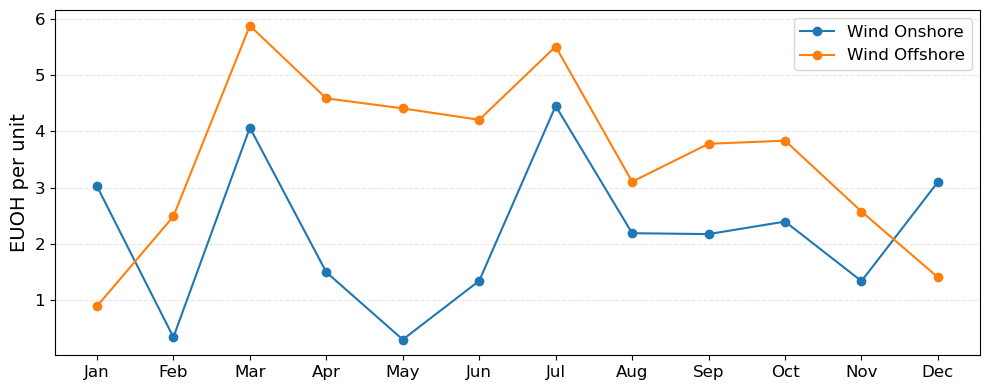

In [37]:
fig, ax = plt.subplots(figsize=(10, 4))

months = range(1, 13)
ax.plot(wind_onshore_df["month"],  wind_onshore_df["equiv_outage_h_per_unit"],
        marker="o", linewidth=1.5, label="Wind Onshore")
ax.plot(wind_offshore_df["month"], wind_offshore_df["equiv_outage_h_per_unit"],
        marker="o", linewidth=1.5, label="Wind Offshore")

ax.set_xticks(list(months))
ax.set_xticklabels(month_labels)
ax.set_ylabel("EUOH per unit")
ax.yaxis.grid(True, alpha=0.3, linestyle="--")
ax.set_axisbelow(True)
ax.legend()
fig.tight_layout()
plt.show()


In [22]:
eoh_rows = []
for variant in _COST_VARIANTS:
    scenario_dir = pypsa_eur_root / "resources" / CONFIG_NAME / SCENARIO_VARIANTS[f"dis_{variant}"]
    base_net_v   = pypsa.Network(NETWORK_PATHS[f"base_{variant}"])

    for carrier in WIND_CARRIERS:
        dmg_path = scenario_dir / "damage_profiles" / f"{carrier}_damage_{CLUSTERS}.nc"
        if not dmg_path.exists():
            continue
        damage_df, p_max_pu_df, _ = _load_damage_aligned(dmg_path, base_net_v, carrier)

        monthly = (damage_df * p_max_pu_df).resample("MS").sum()

        melted = monthly.stack().rename("eoh").reset_index()
        melted.columns = ["month", "bus", "eoh"]
        melted["variant"] = variant
        melted["carrier"] = carrier
        eoh_rows.append(melted)

eoh_df = pd.concat(eoh_rows, ignore_index=True)[["variant", "carrier", "bus", "month", "eoh"]]
eoh_df


INFO:pypsa.network.io:New version 1.2.4 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.4 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.4 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.4 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks


,variant,carrier,bus,month,eoh
0,LGLP,onwind,GB0 0,2021-06-01,0.000000
1,LGLP,onwind,GB0 1,2021-06-01,0.000000
2,LGLP,onwind,GB0 2,2021-06-01,0.000000
3,LGLP,onwind,GB0 3,2021-06-01,0.000000
4,LGLP,onwind,GB1 0,2021-06-01,0.000000
...,...,...,...,...,...
715,HGHP,offwind-dc,GB0 0,2022-05-01,0.000000
716,HGHP,offwind-dc,GB0 1,2022-05-01,0.000000
717,HGHP,offwind-dc,GB0 2,2022-05-01,0.463406
718,HGHP,offwind-dc,GB0 3,2022-05-01,0.000000


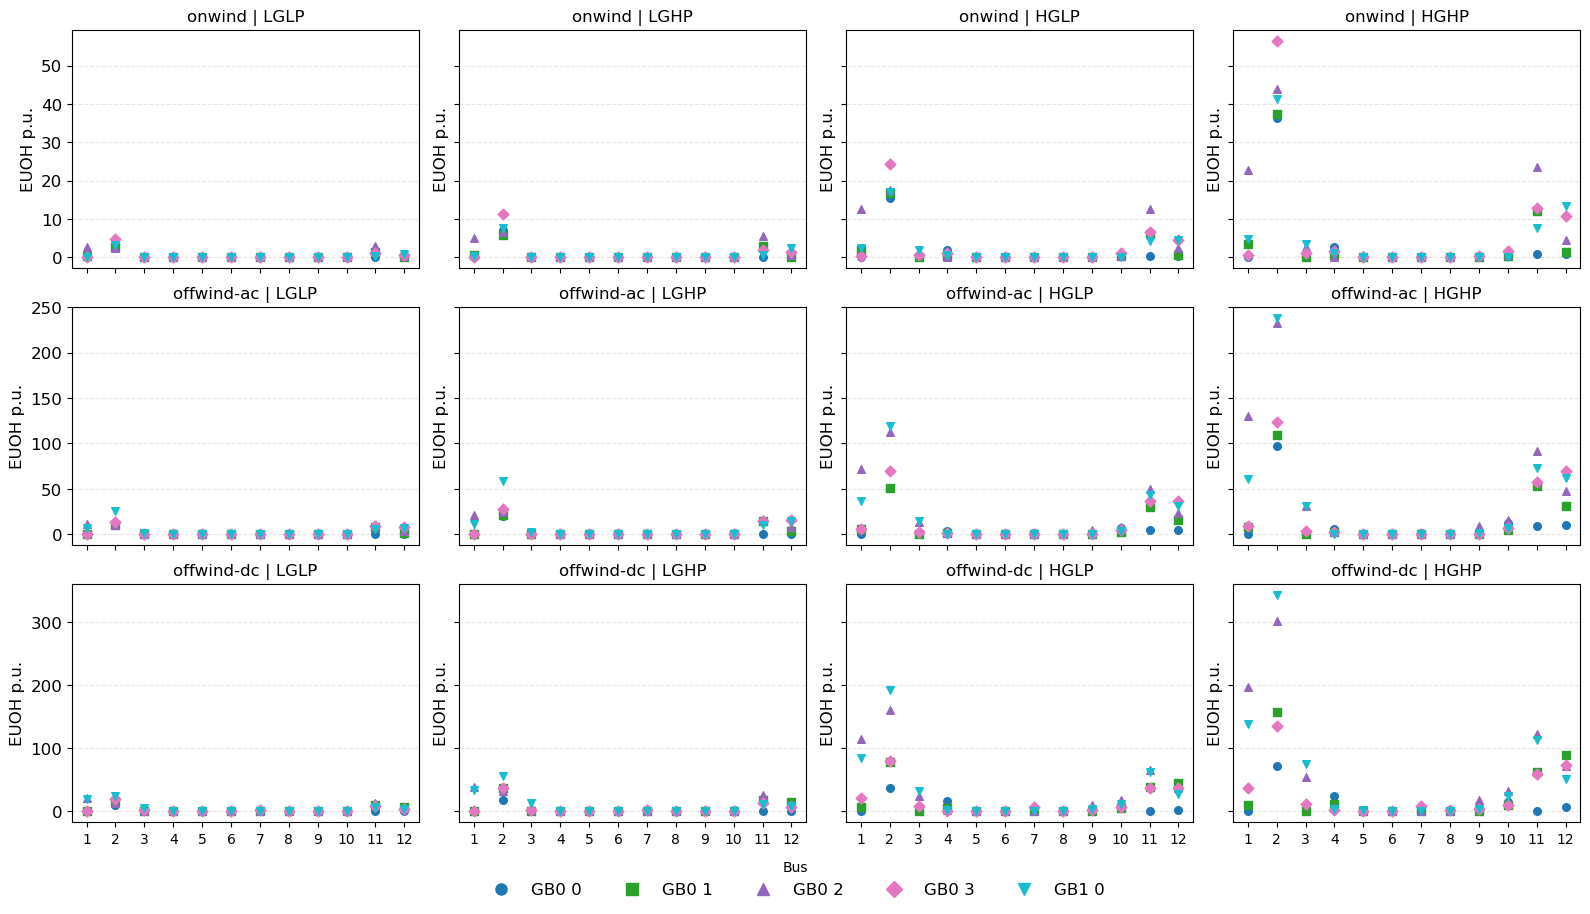

In [36]:
combos = [(c, v) for c in eoh_df["carrier"].unique() for v in _COST_VARIANTS]
ncols = len(_COST_VARIANTS)
nrows = eoh_df["carrier"].nunique()

month_labels = [pd.Timestamp(f"2000-{m:02d}-01").strftime("%b") for m in range(1, 13)]
buses = sorted(eoh_df["bus"].unique())
bus_colors  = dict(zip(buses, plt.cm.tab10(np.linspace(0, 0.9, len(buses)))))
bus_markers = dict(zip(buses, ["o", "s", "^", "D", "v", "P", "X", "*"][:len(buses)]))

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows), sharex=True, sharey="row")

for ax, (carrier, variant) in zip(axes.flat, combos):
    subset = eoh_df[(eoh_df["carrier"] == carrier) & (eoh_df["variant"] == variant)]
    for bus, grp in subset.groupby("bus"):
        grp = grp.sort_values("month")
        ax.scatter(grp["month"].dt.month, grp["eoh"],
                   color=bus_colors[bus], marker=bus_markers[bus], s=30, label=bus)
    ax.set_title(f"{carrier} | {variant}", fontsize=12)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(range(1, 13), rotation=0, fontsize=10)

    ax.set_ylabel("EUOH p.u.", fontsize=12)
    ax.yaxis.grid(True, alpha=0.3, linestyle="--")
    ax.set_axisbelow(True)

axes.flat[0].set_xlim(0.5, 12.5)

handles = [
    plt.Line2D([0], [0], marker=bus_markers[b], color="w", markerfacecolor=bus_colors[b],
               markeredgecolor=bus_colors[b], markersize=8, label=b)
    for b in buses
]
fig.legend(handles=handles, title="Bus", loc="lower center",
           ncol=len(buses), frameon=False, bbox_to_anchor=(0.5, -0.02))
fig.tight_layout()
plt.subplots_adjust(bottom=0.08)
plt.show()
